# 04 — Exploratory Data Analysis and Visualisation

## Purpose

The purpose of this notebook is to explore and visualise the integrated PMIP
dataset in order to understand the patterns, distributions and relationships
within the combined music performance data.

The analysis focuses on Spotify performance metrics, historical chart
performance and artist listener statistics. The findings from this stage will
help identify meaningful relationships, unusual observations and potentially
useful variables before feature engineering and machine-learning development.

## Objectives

The objectives of this notebook are to:

- inspect the structure and quality of the integrated dataset;
- analyse the distributions of important music performance variables;
- examine artist, track and release characteristics;
- investigate historical chart performance across the integrated records;
- explore relationships between Spotify, listener and historical chart metrics;
- identify correlations between numerical features;
- detect important outliers and unusual performance patterns;
- identify potentially useful predictive features and target variables;
- document data limitations that may affect later analysis; and
- provide evidence-based recommendations for the feature engineering stage.

## Table of Contents

1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Integrated Dataset Overview](#2-integrated-dataset-overview)
   - [2.1 Dataset Shape](#21-dataset-shape)
   - [2.2 Column Overview](#22-column-overview)
   - [2.3 Data Types](#23-data-types)
   - [2.4 Missing Data Review](#24-missing-data-review)
3. [Numerical Feature Analysis](#3-numerical-feature-analysis)
   - [3.1 Spotify Performance Metrics](#31-spotify-performance-metrics)
   - [3.2 Historical Chart Metrics](#32-historical-chart-metrics)
   - [3.3 Artist Listener Metrics](#33-artist-listener-metrics)
4. [Distribution Analysis](#4-distribution-analysis)
   - [4.1 Spotify Streams Distribution](#41-spotify-streams-distribution)
   - [4.2 Spotify Popularity Distribution](#42-spotify-popularity-distribution)
   - [4.3 Track Score Distribution](#43-track-score-distribution)
   - [4.4 Artist Listener Distribution](#44-artist-listener-distribution)
5. [Categorical Analysis](#5-categorical-analysis)
   - [5.1 Explicit and Non-Explicit Tracks](#51-explicit-and-non-explicit-tracks)
   - [5.2 Release Year Analysis](#52-release-year-analysis)
   - [5.3 Artist and Track Frequency](#53-artist-and-track-frequency)
6. [Historical Chart Performance Analysis](#6-historical-chart-performance-analysis)
   - [6.1 Best Chart Position](#61-best-chart-position)
   - [6.2 Countries Charted](#62-countries-charted)
   - [6.3 Chart Observation Frequency](#63-chart-observation-frequency)
   - [6.4 Historical Chart Streams](#64-historical-chart-streams)
7. [Feature Relationship Analysis](#7-feature-relationship-analysis)
   - [7.1 Spotify Streams vs Popularity](#71-spotify-streams-vs-popularity)
   - [7.2 Spotify Streams vs Track Score](#72-spotify-streams-vs-track-score)
   - [7.3 Artist Listeners vs Spotify Streams](#73-artist-listeners-vs-spotify-streams)
   - [7.4 Historical Performance vs Current Performance](#74-historical-performance-vs-current-performance)
8. [Correlation Analysis](#8-correlation-analysis)
   - [8.1 Correlation Matrix](#81-correlation-matrix)
   - [8.2 Strongest Positive Relationships](#82-strongest-positive-relationships)
   - [8.3 Strongest Negative Relationships](#83-strongest-negative-relationships)
9. [Outlier Analysis](#9-outlier-analysis)
   - [9.1 Streaming Outliers](#91-streaming-outliers)
   - [9.2 Listener Outliers](#92-listener-outliers)
   - [9.3 Chart Performance Outliers](#93-chart-performance-outliers)
10. [EDA Findings and ML Implications](#10-eda-findings-and-ml-implications)
    - [10.1 Key Findings](#101-key-findings)
    - [10.2 Potential Predictive Features](#102-potential-predictive-features)
    - [10.3 Potential Target Variables](#103-potential-target-variables)
    - [10.4 Data Limitations](#104-data-limitations)
    - [10.5 Recommendations for Feature Engineering](#105-recommendations-for-feature-engineering)

# 1. Setup and Data Loading

This section prepares the Python environment for exploratory data analysis and
loads the integrated PMIP dataset produced during the data integration stage.

The integrated dataset combines Spotify 2024 performance data, historical chart
performance features and artist listener statistics. This dataset will form the
main basis of the exploratory analysis conducted throughout this notebook.

In [2]:
# Import libraries required for exploratory data analysis

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure pandas display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("EDA libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


EDA libraries imported successfully.


### Load the Integrated Dataset

The final integrated PMIP dataset is loaded for exploratory analysis. This
dataset was produced during the data integration stage and contains the combined
Spotify performance metrics, historical chart features and artist listener
statistics.

The file path is checked before loading to confirm that the expected integrated
dataset is available.

In [3]:
# Define the path to the integrated PMIP dataset

data_path = Path("../data/integrated/spotify_integrated.csv")

print("Dataset path:", data_path)
print("Dataset exists:", data_path.exists())

Dataset path: ../data/integrated/spotify_integrated.csv
Dataset exists: True


### Read the Integrated Dataset

The integrated CSV file is now loaded into a Pandas DataFrame named `df`.
Loading the dataset into a DataFrame allows its rows, columns and features to
be examined and analysed throughout the exploratory data analysis.

A confirmation message and the dataset dimensions are displayed after loading
to verify that the file has been read successfully.

In [4]:
# Load the integrated PMIP dataset

df = pd.read_csv(data_path)

print("Integrated PMIP dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Integrated PMIP dataset loaded successfully.
Rows: 4,593
Columns: 42


### Setup and Data Loading Summary

The integrated PMIP dataset loaded successfully and contains **4,593 records
and 42 features**.

Each record represents an observation from the integrated music dataset, while
the 42 columns contain the Spotify performance metrics, historical chart
features, artist listener statistics and supporting track information produced
during the previous data preparation stages.

The successful loading of the dataset confirms that the integrated data is
available and ready for exploratory analysis.

# 2. Integrated Dataset Overview

This section examines the overall structure and quality of the integrated PMIP
dataset before analysing individual performance features.

The analysis reviews the dataset dimensions, available columns, data types and
missing values. This provides an initial understanding of how the integrated
data is organised and identifies any structural or data-quality considerations
that should be taken into account during the exploratory analysis.

## 2.1 Dataset Shape

The dimensions of the integrated dataset are examined to confirm the number of
records and features available for analysis.

In [5]:
# Examine the dimensions of the integrated dataset

rows, columns = df.shape

print(f"Number of rows: {rows:,}")
print(f"Number of columns: {columns:,}")
print(f"Dataset shape: {df.shape}")

Number of rows: 4,593
Number of columns: 42
Dataset shape: (4593, 42)


### Interpretation

The integrated PMIP dataset contains **4,593 rows and 42 columns**. The rows
represent the integrated track records available for analysis, while the columns
contain the original music attributes together with the historical chart and
artist listener features added during data integration.

The dataset therefore provides a combination of track-level, artist-level and
historical performance information that can be explored during the EDA stage.

## 2.2 Column Overview

The column names are examined to understand the features available in the
integrated dataset and to identify the different types of information that can
be used throughout the exploratory analysis.

In [6]:
# Display all columns in the integrated dataset

print(f"Total columns: {len(df.columns)}\n")

for number, column in enumerate(df.columns, start=1):
    print(f"{number:>2}. {column}")

Total columns: 42

 1. Track
 2. Album Name
 3. Artist
 4. Release Date
 5. ISRC
 6. All Time Rank
 7. Track Score
 8. Spotify Streams
 9. Spotify Playlist Count
10. Spotify Playlist Reach
11. Spotify Popularity
12. YouTube Views
13. YouTube Likes
14. TikTok Posts
15. TikTok Likes
16. TikTok Views
17. YouTube Playlist Reach
18. Apple Music Playlist Count
19. AirPlay Spins
20. SiriusXM Spins
21. Deezer Playlist Count
22. Deezer Playlist Reach
23. Amazon Playlist Count
24. Pandora Streams
25. Pandora Track Stations
26. Shazam Counts
27. Explicit Track
28. track_normalised
29. artist_normalised
30. best_chart_position
31. average_chart_position
32. chart_observations
33. countries_charted
34. total_historical_streams
35. average_historical_streams
36. max_historical_streams
37. first_chart_date
38. last_chart_date
39. Listeners
40. Daily Trend
41. Peak
42. PkListeners


### Interpretation

The integrated dataset contains **42 columns** representing several different
types of music information. These include track and artist identifiers, release
information, streaming and playlist performance metrics, social-platform
engagement measures, historical chart features and artist listener statistics.

The range of available features allows the exploratory analysis to examine
music performance from multiple perspectives rather than relying on a single
streaming metric. These features will be investigated more closely in the
following sections to determine their distributions, relationships and potential
value for later machine-learning development.

## 2.3 Data Types

The data types of the 42 integrated features are examined to determine how each
column is currently represented by Pandas.

This is important because numerical features need appropriate numeric data types
for statistical analysis and visualisation, while textual, identifier and date
features may require different treatment during later stages of the analysis.

In [7]:
# Examining the data types of all integrated features

data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

data_types

,Column,Data Type
0,Track,str
1,Album Name,str
2,Artist,str
3,Release Date,str
4,ISRC,str
5,All Time Rank,int64
6,Track Score,float64
7,Spotify Streams,float64
8,Spotify Playlist Count,float64
9,Spotify Playlist Reach,float64


### Interpretation

The integrated dataset contains a mixture of textual, integer and continuous
numerical features.

Track information such as `Track`, `Album Name`, `Artist` and `ISRC` is stored
as string data. The normalised track and artist fields are also represented as
strings and primarily support matching and identification.

Most music performance variables are stored as `float64`, including Spotify
streams and popularity, playlist metrics, social-platform engagement measures,
historical chart statistics and artist listener features. This makes these
variables suitable for the numerical and statistical analyses planned later in
the notebook.

`All Time Rank` and `Explicit Track` are represented as integer values. Although
`Explicit Track` is numeric, it represents a categorical characteristic rather
than a continuous measurement and should therefore be interpreted accordingly.

The date-related columns `Release Date`, `first_chart_date` and
`last_chart_date` are currently stored as strings. These may need to be
temporarily converted to datetime values when performing release-date or
historical time-based analysis later in the EDA.

Overall, the dataset is largely represented using appropriate data types for
exploratory analysis, with date features requiring particular attention during
time-based analysis.

## 2.4 Missing Data Review

Missing values are examined across the integrated dataset to understand the
availability and coverage of each feature.

This is particularly important for PMIP because the dataset combines information
from several music data sources. Some tracks may have Spotify information but
lack historical chart records, artist listener statistics or metrics from other
platforms. Understanding this missingness will help determine which features can
be used reliably during later analysis and machine-learning development.

In [8]:
# Calculate missing-value statistics for each column

missing_count = df.isna().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage (%)": missing_percentage
})

# Show only columns containing missing values,
# ordered from highest to lowest missing percentage
missing_summary = (
    missing_summary[missing_summary["Missing Values"] > 0]
    .sort_values("Missing Percentage (%)", ascending=False)
)

print(f"Columns with missing values: {len(missing_summary)}")
print(f"Columns without missing values: {df.shape[1] - len(missing_summary)}")

missing_summary

Columns with missing values: 32
Columns without missing values: 10


,Missing Values,Missing Percentage (%)
last_chart_date,2358,51.34
first_chart_date,2358,51.34
max_historical_streams,2358,51.34
average_historical_streams,2358,51.34
total_historical_streams,2358,51.34
countries_charted,2358,51.34
chart_observations,2358,51.34
average_chart_position,2358,51.34
best_chart_position,2358,51.34
SiriusXM Spins,2118,46.11


### Interpretation

Missing values are present in **32 of the 42 columns**, while 10 columns contain
complete data. However, the amount of missing data varies considerably between
features.

The largest missing-data pattern occurs across the historical chart features.
`best_chart_position`, `average_chart_position`, `chart_observations`,
`countries_charted`, the historical streaming measures, and the first and last
chart dates each contain **2,358 missing values (51.34%)**. The identical
missingness across these fields indicates that historical chart information is
available only for the subset of integrated tracks that could be associated
with historical chart records.

Artist listener features (`Listeners`, `Daily Trend`, `Peak` and `PkListeners`)
each contain **1,204 missing values (26.21%)**, showing that listener statistics
are available for a larger proportion of the integrated dataset than historical
chart information, but still do not cover every record.

Several cross-platform performance features also contain moderate levels of
missingness. For example, `SiriusXM Spins` is missing for **46.11%** of records,
while Pandora, TikTok, Deezer, Amazon Music and YouTube playlist features show
different levels of incomplete coverage.

The main Spotify measures provide comparatively stronger coverage.
`Spotify Streams` is missing for only **2.35%** of records,
`Spotify Playlist Reach` for **1.46%**, and `Spotify Playlist Count` for
**1.42%**. `Spotify Popularity`, however, has a higher missing rate of
**17.40%**.

These results show that missing values in PMIP are strongly related to the
different coverage provided by the source datasets and music platforms.
Missing values should therefore not automatically be interpreted as zero
performance. Their treatment will need to depend on the meaning and source of
each feature during later feature engineering and machine-learning development.

# 3. Numerical Feature Analysis

This section examines the numerical performance features contained in the
integrated PMIP dataset.

Descriptive statistics are used to understand the typical values, variation and
range of important music performance metrics before their distributions and
relationships are visualised in later sections.

The analysis is divided into Spotify performance metrics, historical chart
metrics and artist listener metrics.

## 3.1 Spotify Performance Metrics

Spotify performance features provide information about how tracks perform on
Spotify through streaming activity, playlist exposure and popularity.

This subsection examines the descriptive statistics of `Spotify Streams`,
`Spotify Playlist Count`, `Spotify Playlist Reach` and `Spotify Popularity`.
The analysis includes the number of available observations, mean, standard
deviation, minimum, quartiles and maximum values for each feature.

In [9]:
# Select the main Spotify performance metrics

spotify_metrics = [
    "Spotify Streams",
    "Spotify Playlist Count",
    "Spotify Playlist Reach",
    "Spotify Popularity"
]

# Calculate descriptive statistics
spotify_summary = df[spotify_metrics].describe().T

spotify_summary

,count,mean,std,min,25%,50%,75%,max
Spotify Streams,"4,485.00","447,406,866.92","538,550,400.79","1,071.00","70,354,552.00","239,850,720.00","629,102,459.00","4,281,468,720.00"
Spotify Playlist Count,"4,528.00","59,397.51","71,145.60",1.00,"6,705.00","32,312.50","86,083.25","590,392.00"
Spotify Playlist Reach,"4,526.00","23,351,766.97","29,692,793.81",1.00,"4,789,848.50","13,264,111.50","29,668,021.50","262,343,414.00"
Spotify Popularity,"3,794.00",63.50,16.19,1.00,61.00,67.00,73.00,96.00


### Interpretation

The descriptive statistics show substantial variation in Spotify performance
across the tracks in the integrated PMIP dataset.

`Spotify Streams` contains 4,485 available observations. The average is
approximately **447.4 million streams**, while the median is approximately
**239.9 million**. The maximum exceeds **4.28 billion streams**, compared with
a 75th percentile of approximately **629.1 million**. The large difference
between the median, mean and maximum suggests that a relatively small number of
very highly streamed tracks may be influencing the overall average.

`Spotify Playlist Count` shows a similar pattern. The median track appears in
approximately **32,313 playlists**, compared with an average of approximately
**59,398**, while the maximum reaches **590,392 playlists**.

`Spotify Playlist Reach` also varies considerably. The median is approximately
**13.26 million**, while the average is approximately **23.35 million** and the
maximum exceeds **262.34 million**. This indicates large differences in playlist
exposure between tracks.

`Spotify Popularity` has 3,794 available observations and is more concentrated
than the other Spotify measures. Its median value is **67**, with the middle
50% of observations ranging from **61 to 73**. The maximum observed popularity
score is **96**.

Overall, the large gaps between typical and maximum values for streams and
playlist metrics indicate that Spotify performance is highly unequal across
tracks. These patterns will be investigated more directly through distribution
visualisations and outlier analysis later in the notebook.

## 3.2 Historical Chart Metrics

Historical chart features describe the previous chart performance of tracks
that were successfully associated with records from the historical Spotify
charts dataset.

This subsection examines chart position, chart frequency, geographic reach and
historical streaming activity. Descriptive statistics are calculated only from
the available historical observations; missing values represent tracks for
which matched historical chart information is not available.

In [10]:
# Select the historical chart performance metrics

historical_metrics = [
    "best_chart_position",
    "average_chart_position",
    "chart_observations",
    "countries_charted",
    "total_historical_streams",
    "average_historical_streams",
    "max_historical_streams"
]

# Calculate descriptive statistics
historical_summary = df[historical_metrics].describe().T

historical_summary

,count,mean,std,min,25%,50%,75%,max
best_chart_position,"2,235.00",22.97,38.72,1.00,1.00,6.00,25.00,270.00
average_chart_position,"2,235.00",100.33,34.71,6.11,78.31,96.27,120.06,270.00
chart_observations,"2,235.00","1,022.54","1,550.06",1.00,70.00,409.00,"1,323.50","13,860.00"
countries_charted,"2,235.00",30.27,23.40,1.00,8.00,24.00,54.00,74.00
total_historical_streams,"2,235.00","419,984,430.43","645,357,916.00","1,904.00","32,887,104.00","171,706,002.00","534,224,802.50","6,226,855,629.00"
average_historical_streams,"2,235.00","585,288.93","578,920.57","1,560.00","237,524.18","440,868.67","718,015.15","6,320,841.50"
max_historical_streams,"2,235.00","11,814,935.81","12,924,714.55","1,560.00","2,425,893.00","8,020,928.00","16,480,270.00","115,156,896.00"


### Interpretation

Historical chart statistics are available for **2,235 tracks** in the integrated
dataset. These statistics describe the performance of tracks for which matching
historical chart records were available.

The median `best_chart_position` is **6**, meaning that half of the matched
tracks achieved a best recorded chart position of 6 or better. The 25th
percentile is **1**, showing that at least one quarter of these tracks reached
the top chart position in at least one recorded market or observation. The mean
best position is approximately **22.97**, indicating considerable variation
between tracks.

The `average_chart_position` has a median of approximately **96.27** and a mean
of approximately **100.33**. This is considerably lower in ranking performance
than the typical best position, which is expected because a track's best chart
position represents its strongest recorded result, while its average considers
its wider historical chart activity.

Historical chart activity also varies substantially between tracks. The median
number of chart observations is **409**, compared with an average of
approximately **1,023** and a maximum of **13,860** observations. This suggests
that some tracks remained present across considerably more chart records than
others.

The median track charted across **24 countries**, while the average is
approximately **30 countries** and the maximum is **74 countries**. This
indicates substantial differences in the geographic reach of historically
charted tracks.

Historical streaming performance also shows large variation. Median total
historical streams are approximately **171.7 million**, compared with an
average of approximately **420.0 million** and a maximum exceeding
**6.22 billion**. Similar differences between typical and maximum values are
visible in the average and maximum historical streaming measures.

Overall, the historical features capture several different dimensions of music
performance, including chart success, persistence, geographic reach and
streaming activity. The large ranges observed in several measures suggest that
their distributions and possible extreme values should be investigated further
during the distribution and outlier analysis stages.

## 3.3 Artist Listener Metrics

Artist listener features provide artist-level information about audience size
and recent listener activity.

This subsection examines `Listeners`, `Daily Trend`, `Peak` and `PkListeners`
to understand the scale and variation of artist audience metrics represented
within the integrated dataset. These features originate at artist level and may
therefore be repeated across multiple tracks belonging to the same artist.

In [11]:
# Select the artist listener metrics

listener_metrics = [
    "Listeners",
    "Daily Trend",
    "Peak",
    "PkListeners"
]

# Calculate descriptive statistics
listener_summary = df[listener_metrics].describe().T

listener_summary

,count,mean,std,min,25%,50%,75%,max
Listeners,"3,389.00","31,168,246.74","24,312,165.49","4,281,434.00","11,178,406.00","23,976,058.00","46,559,302.00","107,592,328.00"
Daily Trend,"3,389.00","3,045.85","127,065.17","-368,853.00","-42,758.00","-4,254.00","29,283.00","743,072.00"
Peak,"3,389.00",389.07,493.67,1.00,34.00,167.00,576.00,"2,358.00"
PkListeners,"3,389.00","33,671,018.95","25,721,963.76","4,393,932.00","12,231,275.00","25,280,553.00","52,131,934.00","113,034,886.00"


### Interpretation

Artist listener statistics are available for **3,389 integrated track records**.
Because these measures originate at artist level, the same listener statistics
may appear across multiple tracks belonging to the same artist. The results
should therefore be interpreted as the distribution of listener metrics across
matched track records rather than as 3,389 unique artists.

`Listeners` has a median of approximately **23.98 million**, compared with an
average of approximately **31.17 million**. The maximum exceeds **107.59
million listeners**, while the 75th percentile is approximately **46.56
million**. The difference between the median, mean and maximum indicates
substantial variation in audience size among the represented artists.

`Daily Trend` behaves differently from the other listener measures because it
contains both negative and positive values. The median is approximately
**-4,254**, while the mean is approximately **3,046**. Values range from
approximately **-368,853 to 743,072**, indicating that some artists were losing
listeners while others were experiencing substantial increases at the time the
listener data was recorded.

`Peak` has a median value of **167**, an average of approximately **389**, and a
maximum of **2,358**. This indicates considerable variation in the peak-related
measure across the matched records.

`PkListeners` has a median of approximately **25.28 million** and an average of
approximately **33.67 million**, with a maximum exceeding **113.03 million**.
These values are generally higher than the corresponding current `Listeners`
statistics, which is consistent with the feature representing a peak listener
measure.

Overall, the listener features provide useful information about audience size,
peak performance and recent movement. In particular, `Daily Trend` may be
valuable for later momentum-related analysis because it captures both positive
and negative changes in artist listener activity.

# 4. Distribution Analysis

This section visualises the distributions of selected music performance
features in the integrated PMIP dataset.

Distribution analysis provides a clearer view of how observations are spread
across different performance levels and helps identify characteristics that
may not be obvious from descriptive statistics alone. In particular, the
visualisations can reveal concentration, skewness, long tails and potentially
unusual observations.

The analysis focuses on Spotify streams, Spotify popularity, track score and
artist listener statistics.

## 4.1 Spotify Streams Distribution

Spotify stream counts are visualised to examine how streaming performance is
distributed across tracks.

The previous descriptive analysis showed a substantial difference between the
mean, median and maximum number of Spotify streams. A histogram is therefore
used to investigate whether streaming activity is concentrated among lower and
moderate values or influenced by a smaller number of extremely high-performing
tracks.

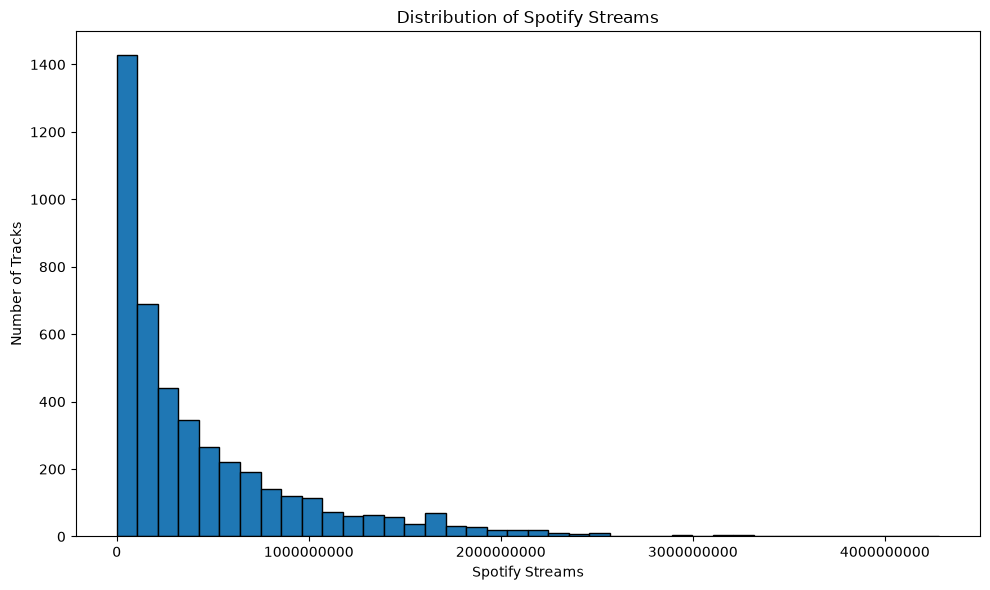

In [12]:
# Prepare non-missing Spotify stream observations

spotify_streams = df["Spotify Streams"].dropna()

# Plot the distribution of Spotify streams
plt.figure(figsize=(10, 6))

plt.hist(spotify_streams, bins=40, edgecolor="black")

plt.title("Distribution of Spotify Streams")
plt.xlabel("Spotify Streams")
plt.ylabel("Number of Tracks")

plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

### Interpretation

The distribution of `Spotify Streams` is strongly **right-skewed**. Most tracks
are concentrated toward the lower end of the streaming range, while the
frequency of tracks decreases as the number of streams increases.

A long right-hand tail is visible, extending beyond **4 billion streams**. This
shows that a relatively small number of extremely high-performing tracks have
stream counts that are substantially larger than those of most tracks in the
dataset.

This visual pattern explains the earlier descriptive statistics, where the mean
Spotify stream count was approximately **447.4 million**, compared with a median
of approximately **239.9 million**. The very highly streamed tracks pull the
mean upward.

The distribution also indicates that Spotify stream counts may require special
consideration during later statistical and machine-learning analysis. For
example, transformations or robust modelling approaches may be investigated
during feature engineering if the extreme differences in scale affect model
performance.

The unusually high observations will be examined more formally during the
outlier analysis stage rather than automatically being treated as errors.

## 4.2 Spotify Popularity Distribution

Spotify popularity scores are visualised to examine how popularity is
distributed across tracks with available Spotify popularity information.

Unlike stream counts, Spotify popularity is represented on a bounded scale.
The histogram therefore helps determine where popularity scores are
concentrated and whether the distribution differs from the strongly skewed
pattern observed for Spotify streams.

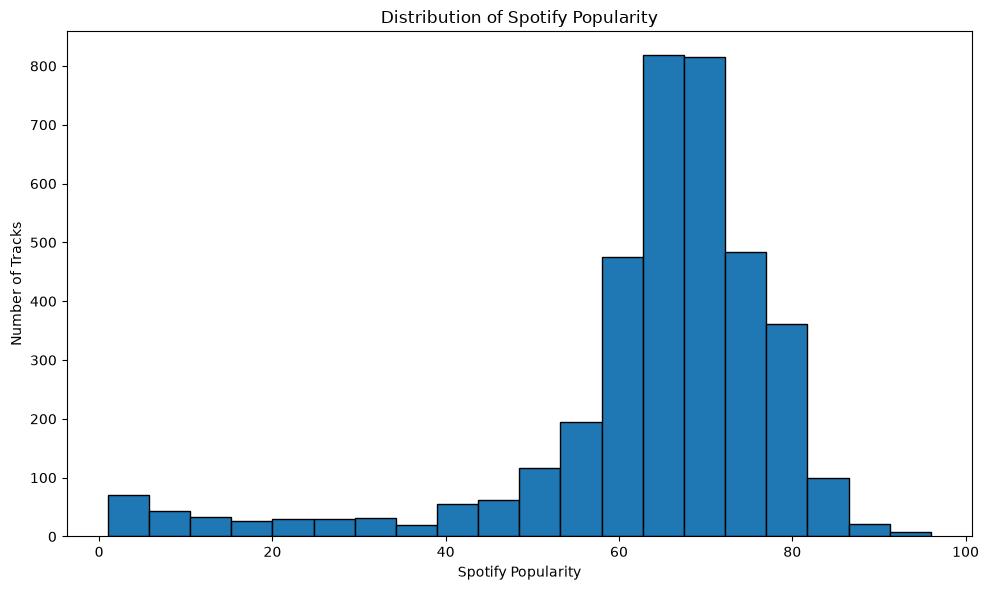

In [13]:
# Prepare non-missing Spotify popularity observations

spotify_popularity = df["Spotify Popularity"].dropna()

# Plot the distribution of Spotify popularity
plt.figure(figsize=(10, 6))

plt.hist(spotify_popularity, bins=20, edgecolor="black")

plt.title("Distribution of Spotify Popularity")
plt.xlabel("Spotify Popularity")
plt.ylabel("Number of Tracks")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of `Spotify Popularity` is concentrated primarily within the
higher-middle range of the popularity scale. Most tracks with available
popularity information have scores between approximately **60 and 80**, with
the greatest concentration occurring around the mid-to-high 60s.

This pattern is consistent with the descriptive statistics observed earlier,
where the median popularity score was **67**, the mean was approximately
**63.5**, and the middle 50% of tracks had scores between **61 and 73**.

Unlike `Spotify Streams`, the popularity distribution does not contain an
extremely long right-hand tail. Instead, a smaller number of tracks extend
toward very low popularity scores, while relatively few tracks approach the
highest observed scores near 100.

The concentration of tracks at moderately high popularity levels may partly
reflect the characteristics of the source dataset, which contains music with
substantial cross-platform performance rather than a random sample of all
Spotify tracks.

Overall, Spotify popularity shows considerably less variation in scale than
Spotify stream counts. This difference should be considered when comparing the
two features and when evaluating their relationships later in the analysis.

## 4.3 Track Score Distribution

The distribution of `Track Score` is examined to understand how the overall
track-performance score varies across the integrated dataset.

The histogram provides a visual indication of whether most tracks have similar
scores or whether a smaller number of tracks achieve substantially higher
values than the majority of observations.

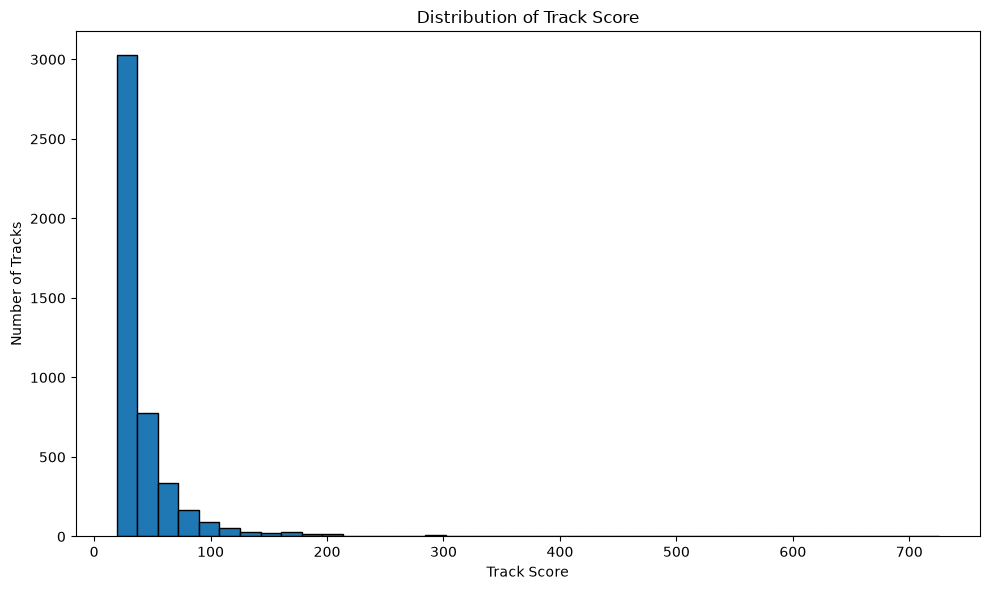

In [14]:
# Prepare non-missing Track Score observations

track_scores = df["Track Score"].dropna()

# Plot the distribution of Track Score
plt.figure(figsize=(10, 6))

plt.hist(track_scores, bins=40, edgecolor="black")

plt.title("Distribution of Track Score")
plt.xlabel("Track Score")
plt.ylabel("Number of Tracks")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of `Track Score` is strongly **right-skewed**. Most tracks are
concentrated within the lower part of the score range, while the number of
observations decreases rapidly as Track Score increases.

A long right-hand tail is visible, with a small number of tracks achieving
substantially higher scores than the majority of the dataset. Most observations
appear below approximately **100**, while a much smaller number extend beyond
this range. An especially high observation is visible above **700**.

This pattern indicates that high Track Scores are relatively uncommon within
the integrated dataset. A small number of exceptionally high-scoring tracks may
therefore have a considerable influence on summary statistics such as the mean.

The extreme values should not automatically be treated as data errors. They may
represent genuinely exceptional track performance and will be examined more
formally during the outlier analysis stage.

The strong skewness of Track Score should also be considered during later
feature engineering and machine-learning development, particularly if the
feature is used as either a predictor or potential target variable.

## 4.4 Artist Listener Distribution

The distribution of artist listener counts is examined to understand how
audience size varies across the integrated track records with available
listener information.

Because listener statistics originate at artist level, artists with multiple
tracks may appear repeatedly within the integrated dataset. The visualisation
therefore represents the distribution of listener values across matched track
records rather than a distribution of unique artists.

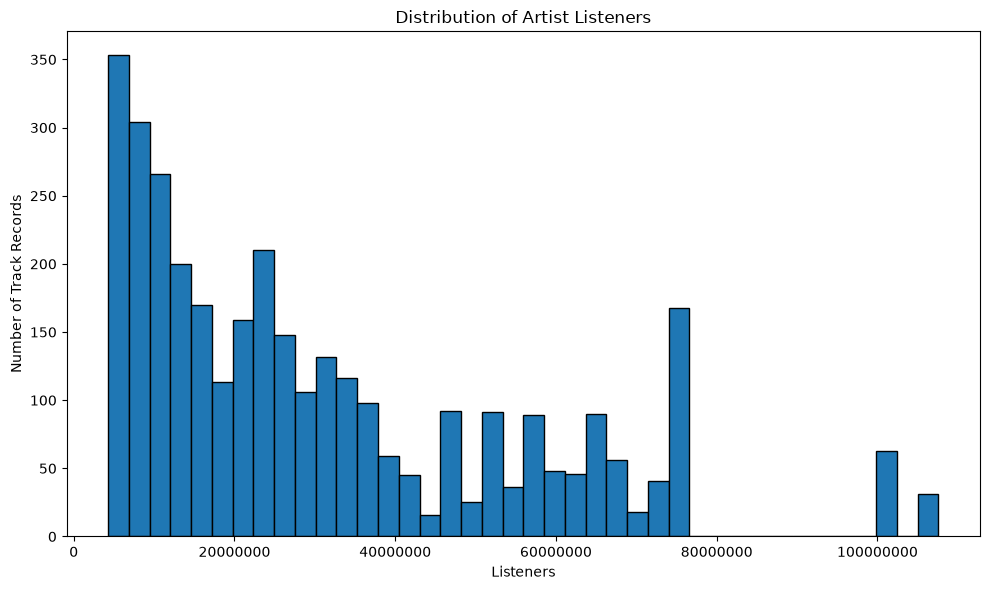

In [15]:
# Prepare non-missing artist listener observations

artist_listeners = df["Listeners"].dropna()

# Plot the distribution of artist listeners
plt.figure(figsize=(10, 6))

plt.hist(artist_listeners, bins=40, edgecolor="black")

plt.title("Distribution of Artist Listeners")
plt.xlabel("Listeners")
plt.ylabel("Number of Track Records")

plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

### Interpretation

The distribution of `Listeners` shows substantial variation in artist audience
size across the matched track records.

A large proportion of observations are concentrated toward the lower and
middle part of the listener range, particularly below approximately **40
million listeners**. However, the distribution also contains several noticeable
concentrations at higher listener levels and extends beyond **100 million
listeners**.

The distribution is not smooth because listener statistics originate at artist
level while the integrated PMIP dataset is organised at track level. Artists
with multiple tracks can therefore contribute the same listener value to
multiple records, which may produce some of the visible peaks in the histogram.

The graph is consistent with the earlier descriptive statistics, where the
median listener count was approximately **23.98 million**, compared with an
average of approximately **31.17 million** and a maximum exceeding **107.59
million**.

Overall, artist audience size varies considerably within the integrated
dataset. These differences may provide useful information for later analysis
of artist performance and momentum, although artist-level duplication should
be considered when interpreting listener-based results.

# 5. Categorical Analysis

This section examines categorical and discrete characteristics of the integrated
PMIP dataset.

The analysis focuses on explicit-content classification, release-year patterns
and the frequency of artists and tracks represented in the dataset. These
features provide additional context about the composition of the data beyond
the numerical performance measures examined previously.

## 5.1 Explicit and Non-Explicit Tracks

The `Explicit Track` feature is examined to compare the number and proportion
of explicit and non-explicit tracks represented in the integrated dataset.

Although this feature is stored numerically, it represents a categorical
characteristic, where the values distinguish tracks according to their
explicit-content classification.

In [16]:
# Examine explicit-content categories

explicit_counts = df["Explicit Track"].value_counts().sort_index()
explicit_percentages = (
    df["Explicit Track"].value_counts(normalize=True).sort_index() * 100
)

explicit_summary = pd.DataFrame({
    "Track Count": explicit_counts,
    "Percentage (%)": explicit_percentages
})

explicit_summary.index.name = "Explicit Track"

explicit_summary

,Track Count,Percentage (%)
Explicit Track,,
0,2942,64.05
1,1651,35.95


### Explicit Content Distribution

The explicit-content classification is visualised below to compare the number
of explicit and non-explicit tracks in the integrated PMIP dataset.

The dataset uses `0` to represent non-explicit tracks and `1` to represent
explicit tracks.

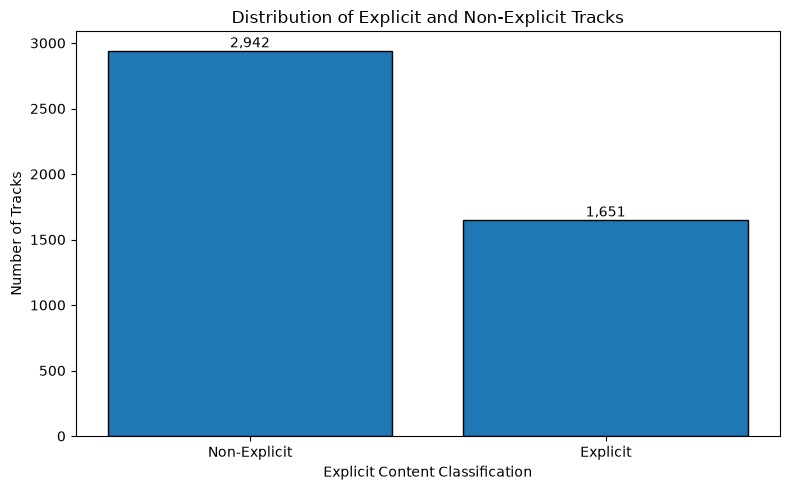

In [17]:
# Create readable labels for the explicit-content categories
explicit_labels = ["Non-Explicit", "Explicit"]
explicit_values = [
    explicit_counts.get(0, 0),
    explicit_counts.get(1, 0)
]

# Plot explicit-content distribution
plt.figure(figsize=(8, 5))

bars = plt.bar(
    explicit_labels,
    explicit_values,
    edgecolor="black"
)

plt.title("Distribution of Explicit and Non-Explicit Tracks")
plt.xlabel("Explicit Content Classification")
plt.ylabel("Number of Tracks")

# Display the number of tracks above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Interpretation

The explicit-content distribution shows that non-explicit tracks represent the
majority of the integrated PMIP dataset.

Of the **4,593 tracks**, **2,942 (64.05%)** are classified as non-explicit,
while **1,651 (35.95%)** are classified as explicit. Therefore, approximately
two-thirds of the tracks are non-explicit and slightly more than one-third are
explicit.

Although the two categories are not evenly represented, both contain a
substantial number of observations. This means that explicit-content
classification can still be investigated later as a possible explanatory
feature when analysing differences in track performance.

At this stage, the distribution only describes the composition of the dataset
and does not demonstrate that explicit or non-explicit content causes stronger
music performance.

## 5.2 Release Year Analysis

Release years are examined to understand the temporal composition of the
integrated PMIP dataset and determine whether particular periods are more
strongly represented than others.

The existing `Release Date` field is converted to a datetime representation
and used to derive a separate `Release Year` feature. The original release-date
values are retained unchanged.

In [18]:
# Convert Release Date to datetime without modifying the original column
release_dates = pd.to_datetime(df["Release Date"], errors="coerce")

# Derive release year
df["Release Year"] = release_dates.dt.year

# Examine release year coverage
print("Valid release years:", df["Release Year"].notna().sum())
print("Missing release years:", df["Release Year"].isna().sum())
print("Earliest release year:", int(df["Release Year"].min()))
print("Latest release year:", int(df["Release Year"].max()))

# Display the number of tracks released in each year
release_year_counts = df["Release Year"].value_counts().sort_index()

release_year_counts

Valid release years: 4593
Missing release years: 0
Earliest release year: 1987
Latest release year: 2024


Release Year
1987       1
1991       1
1994       1
1998       1
1999       1
2000       2
2001       1
2002       5
2003       3
2004       5
2005       5
2006       3
2007       5
2008      11
2009      15
2010      27
2011      51
2012      47
2013      55
2014      70
2015      96
2016     123
2017     212
2018     249
2019     296
2020     360
2021     408
2022     693
2023    1158
2024     688
Name: count, dtype: int64

### Release Year Distribution

The number of tracks associated with each release year is visualised to examine
how the integrated dataset is distributed over time.

Each bar represents the number of track records released during a particular
year. This makes it possible to identify periods that are strongly or weakly
represented within the dataset.

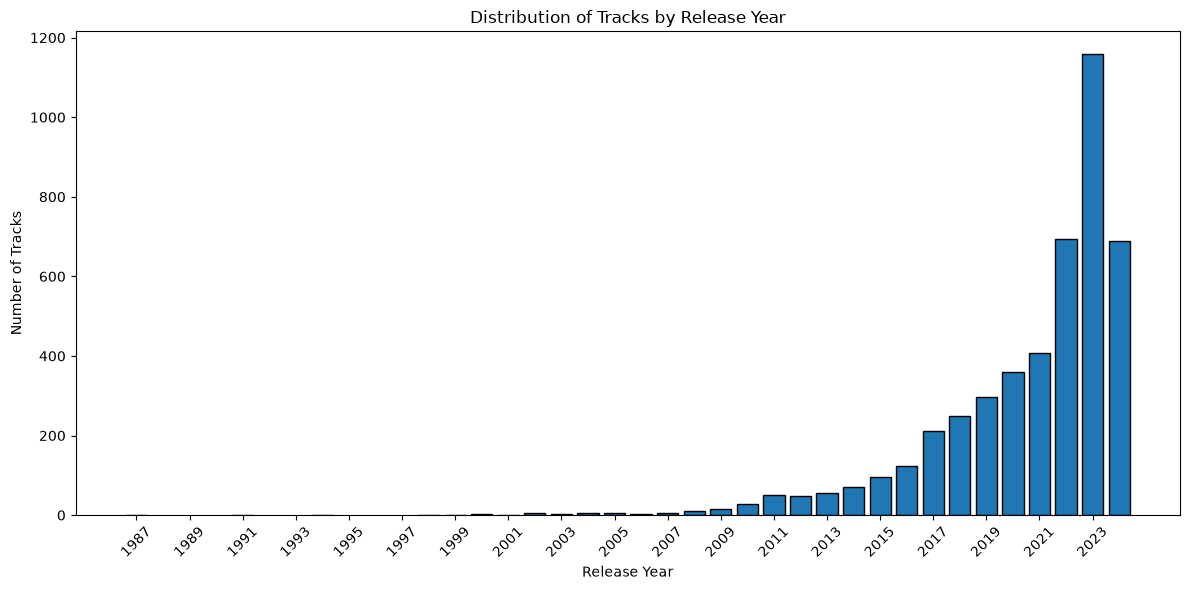

In [19]:
# Plot the number of tracks by release year

plt.figure(figsize=(12, 6))

plt.bar(
    release_year_counts.index.astype(int),
    release_year_counts.values,
    edgecolor="black"
)

plt.title("Distribution of Tracks by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Tracks")

# Display selected years clearly on the x-axis
plt.xticks(
    range(
        int(df["Release Year"].min()),
        int(df["Release Year"].max()) + 1,
        2
    ),
    rotation=45
)

plt.tight_layout()
plt.show()

### Interpretation

The release-year distribution shows that the integrated PMIP dataset is heavily
concentrated toward more recent music releases.

Tracks released before approximately **2010** are relatively uncommon, while
the number of represented tracks increases considerably throughout the late
2010s and early 2020s. This increase becomes particularly noticeable from
around **2017 onwards**.

The largest concentration occurs in **2023**, with **1,158 tracks**, making it
the most strongly represented release year in the dataset. This is followed by
**2022 with 693 tracks** and **2024 with 688 tracks**.

Although the number of tracks decreases between 2023 and 2024, this should not
automatically be interpreted as a decline in music releases. The source dataset
is based on 2024 music-performance data, so the representation of releases from
2024 may reflect the dataset's collection period rather than a complete year of
music releases.

Overall, the dataset contains considerably greater representation of recent
music than older releases. This temporal imbalance should be considered when
interpreting later performance analysis and when developing machine-learning
features or models, since patterns learned from the dataset may be influenced
more strongly by recent releases.

## 5.3 Artist and Track Frequency

Artist and track frequencies are examined to understand how frequently
individual artists and track titles occur within the integrated PMIP dataset.

Because an artist may have multiple releases represented in the dataset,
artist frequency provides an indication of how strongly particular artists are
represented. Track-title frequency is also examined to identify repeated track
names and understand whether track titles alone represent unique records.

In [ ]:
# Examining artist and track frequency

unique_artists = df["Artist"].nunique()
unique_tracks = df["Track"].nunique()

print(f"Total track records: {len(df):,}")
print(f"Unique artists: {unique_artists:,}")
print(f"Unique track titles: {unique_tracks:,}")

# Count the number of records associated with each artist
artist_frequency = df["Artist"].value_counts()

print("\nTop 15 most frequently represented artists:")
artist_frequency.head(15)

Total track records: 4,593
Unique artists: 1,999
Unique track titles: 4,365

Top 15 most frequently represented artists:


Artist
Taylor Swift      63
Drake             63
Bad Bunny         60
KAROL G           32
The Weeknd        31
Travis Scott      30
Billie Eilish     27
Ariana Grande     26
Future            23
Post Malone       22
Peso Pluma        22
Juice WRLD        21
Olivia Rodrigo    20
Morgan Wallen     20
Lil Baby          20
Name: count, dtype: int64

### Visualisation of Most Frequently Represented Artists

The fifteen artist entries with the largest number of track records are
visualised to examine the degree of artist concentration within the dataset.

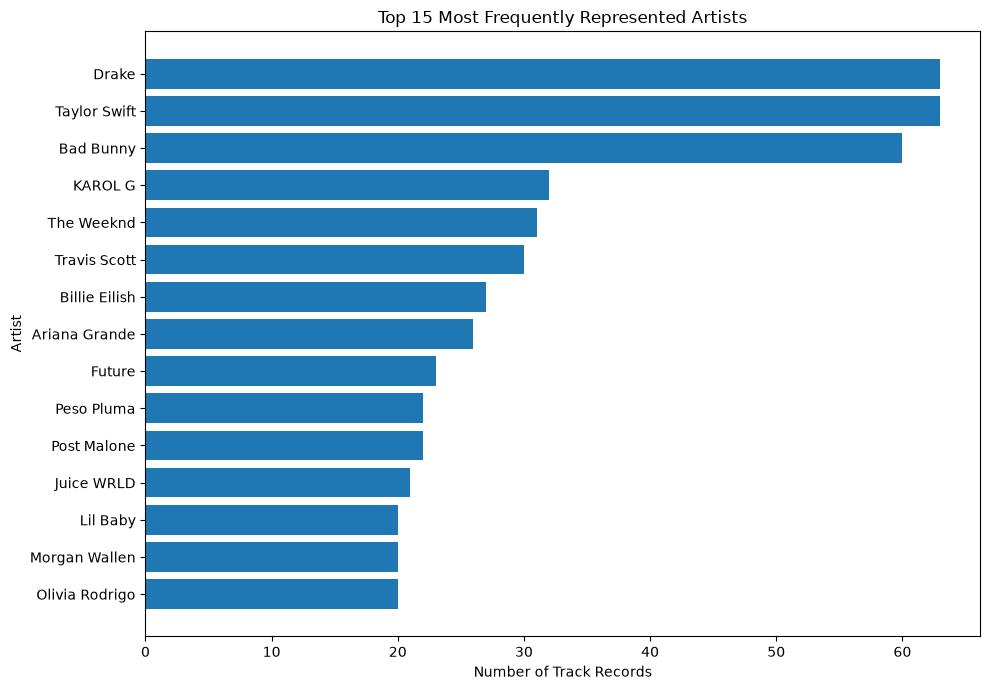

In [21]:
# Select the 15 most frequently represented artists
top_artists = artist_frequency.head(15).sort_values()

# Plot artist frequencies
plt.figure(figsize=(10, 7))

plt.barh(top_artists.index, top_artists.values)

plt.title("Top 15 Most Frequently Represented Artists")
plt.xlabel("Number of Track Records")
plt.ylabel("Artist")

plt.tight_layout()
plt.show()

### Interpretation

The integrated dataset contains 4,593 track records representing 1,999 unique
artists and 4,365 unique track titles. This indicates that the dataset contains
a broad range of artists and tracks, although some artists are represented by
multiple records.

The frequency analysis shows that artist representation is uneven. Taylor Swift
and Drake have the highest representation with 63 track records each, followed
closely by Bad Bunny with 60. There is then a substantial decrease to KAROL G
with 32 records, while the remaining artists within the top fifteen contain
between 20 and 31 track records.

The visualisation therefore shows that a relatively small number of highly
represented artists contribute considerably more records than most other
artists. This is important for later analysis and machine-learning development,
as models trained directly at track level may be influenced more strongly by
artists with multiple records. Artist representation should therefore be
considered when preparing training and testing data and when evaluating model
performance.

# 6. Historical Chart Performance Analysis

This section examines the historical chart performance of tracks within the
integrated PMIP dataset. The historical features were created during the data
integration stage by aggregating observations from the historical Spotify
charts dataset.

The analysis focuses on chart position, geographic reach, chart activity and
historical streaming performance. These variables provide information about
how strongly and widely tracks have performed historically and may provide
useful indicators for later feature engineering and machine-learning
development.

The historical chart analysis is organised into the following areas:

- **6.1 Best Chart Position**
- **6.2 Countries Charted**
- **6.3 Chart Observation Frequency**
- **6.4 Historical Chart Streams**

## 6.1 Best Chart Position

The `best_chart_position` variable represents the highest chart position
achieved by a matched track within the historical chart data.

Because chart rankings work in ascending order, a smaller numerical value
represents stronger chart performance. For example, a value of 1 indicates
that a track reached the number-one position.

This subsection examines the distribution of best chart positions to understand
how strongly the historically matched tracks performed on the charts.

In [22]:
# Prepare non-missing best chart position observations
best_chart_positions = df["best_chart_position"].dropna()

# Examine the best chart position variable
print(f"Tracks with historical chart data: {len(best_chart_positions):,}")
print(f"Tracks without historical chart data: {df['best_chart_position'].isna().sum():,}")

print(f"\nBest chart position: {best_chart_positions.min():,.0f}")
print(f"Worst best-chart position: {best_chart_positions.max():,.0f}")
print(f"Median best chart position: {best_chart_positions.median():,.0f}")
print(f"Mean best chart position: {best_chart_positions.mean():,.2f}")

# Count tracks reaching important chart thresholds
print("\nChart performance thresholds:")
print(f"Reached #1: {(best_chart_positions == 1).sum():,}")
print(f"Reached Top 10: {(best_chart_positions <= 10).sum():,}")
print(f"Reached Top 50: {(best_chart_positions <= 50).sum():,}")
print(f"Reached Top 100: {(best_chart_positions <= 100).sum():,}")

Tracks with historical chart data: 2,235
Tracks without historical chart data: 2,358

Best chart position: 1
Worst best-chart position: 270
Median best chart position: 6
Mean best chart position: 22.97

Chart performance thresholds:
Reached #1: 609
Reached Top 10: 1,369
Reached Top 50: 1,893
Reached Top 100: 2,092


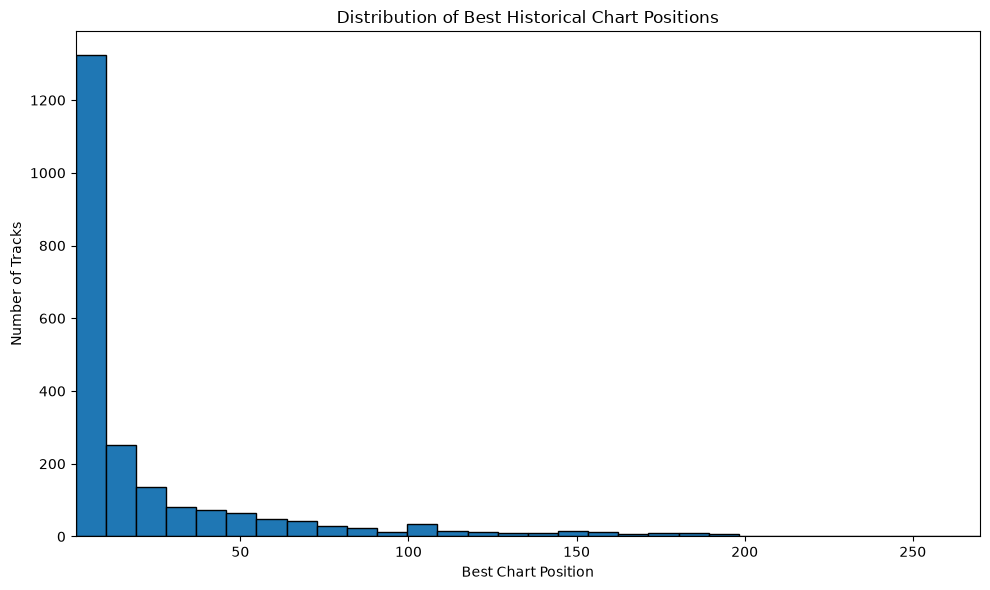

In [23]:
# Visualise the distribution of best historical chart positions

plt.figure(figsize=(10, 6))

plt.hist(
    best_chart_positions,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Best Historical Chart Positions")
plt.xlabel("Best Chart Position")
plt.ylabel("Number of Tracks")

# Chart position 1 represents the strongest performance
plt.xlim(1, best_chart_positions.max())

plt.tight_layout()
plt.show()

### Interpretation

The distribution of best historical chart positions is strongly concentrated
towards the highest-ranking positions. Among the 2,235 tracks with matched
historical chart data, 609 tracks reached the number-one position and 1,369
reached the Top 10.

The median best chart position is 6, compared with a mean of approximately
22.97. This difference is influenced by a smaller number of tracks whose best
historical positions occurred much further down the chart, with the observed
values extending as far as position 270.

The histogram supports this pattern, showing a large concentration of tracks
near the strongest chart positions followed by a long tail towards weaker
positions. Overall, the matched historical subset contains a substantial
number of tracks with strong previous chart performance.

This is important for later PMIP development because historical chart position
may provide a useful indicator of established track performance. However,
historical chart information is available for only 2,235 of the 4,593 records,
so the missing historical coverage must be considered during feature
engineering and machine-learning development.

## 6.2 Countries Charted

The `countries_charted` variable represents the number of different countries
in which a matched track appeared within the historical Spotify chart data.

Unlike chart position, a larger value generally represents broader geographic
reach. A track appearing in many countries may indicate stronger international
visibility, while a track appearing in fewer countries may have had a more
localised or limited chart presence.

This subsection examines the distribution of countries charted to understand
the geographic reach of historically matched tracks. This information may also
support the geographic performance intelligence and market analysis components
of PMIP.

In [24]:
# Prepare non-missing countries-charted observations
countries_charted = df["countries_charted"].dropna()

# Examine geographic chart coverage
print(f"Tracks with geographic chart data: {len(countries_charted):,}")
print(
    f"Tracks without geographic chart data: "
    f"{df['countries_charted'].isna().sum():,}"
)

print(f"\nMinimum countries charted: {countries_charted.min():,.0f}")
print(f"Maximum countries charted: {countries_charted.max():,.0f}")
print(f"Median countries charted: {countries_charted.median():,.0f}")
print(f"Mean countries charted: {countries_charted.mean():,.2f}")

# Examine useful geographic-reach thresholds
print("\nGeographic reach thresholds:")
print(f"Charted in at least 5 countries: {(countries_charted >= 5).sum():,}")
print(f"Charted in at least 10 countries: {(countries_charted >= 10).sum():,}")
print(f"Charted in at least 25 countries: {(countries_charted >= 25).sum():,}")
print(f"Charted in at least 50 countries: {(countries_charted >= 50).sum():,}")

Tracks with geographic chart data: 2,235
Tracks without geographic chart data: 2,358

Minimum countries charted: 1
Maximum countries charted: 74
Median countries charted: 24
Mean countries charted: 30.27

Geographic reach thresholds:
Charted in at least 5 countries: 1,819
Charted in at least 10 countries: 1,620
Charted in at least 25 countries: 1,113
Charted in at least 50 countries: 644


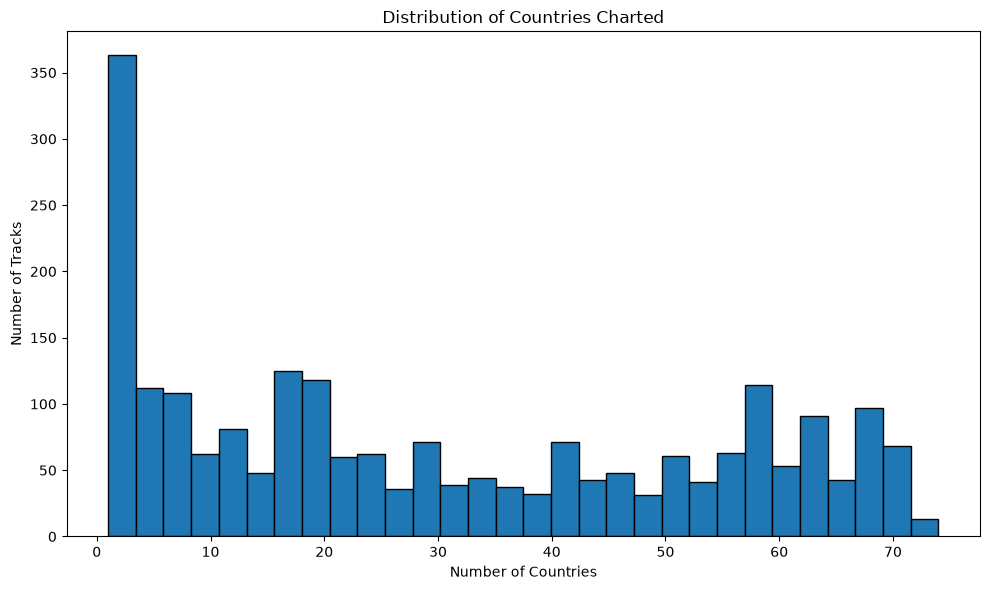

In [25]:
# Visualise the distribution of countries charted

plt.figure(figsize=(10, 6))

plt.hist(
    countries_charted,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Countries Charted")
plt.xlabel("Number of Countries")
plt.ylabel("Number of Tracks")

plt.tight_layout()
plt.show()

### Interpretation

The distribution shows substantial variation in the geographic reach of tracks within the historical chart data. A large concentration of tracks charted in only a small number of countries, indicating that some releases had relatively limited geographic chart coverage. However, the distribution also extends across a wide range of markets, with some tracks appearing in as many as 74 countries.

The median track charted in 24 countries, while the mean was approximately 30 countries. The higher mean suggests that tracks with particularly broad international reach increase the overall average. In addition, 644 tracks charted in at least 50 countries, demonstrating that a meaningful proportion of the matched tracks achieved wide international chart exposure.

This variation may be useful for PMIP because `countries_charted` provides a measurable indicator of geographic reach. It could later contribute to features representing international market penetration and geographic performance, although the number of countries alone does not indicate how strongly a track performed within each individual market.

## 6.3 Chart Observation Frequency

This section examines the number of historical chart observations associated with each matched track. Chart observation frequency provides an indication of how frequently a track appeared within the historical chart dataset and may therefore provide useful information about chart persistence and sustained performance.

In [26]:
# Analyse historical chart observation frequency

chart_observations = df["chart_observations"].dropna()

print(f"Tracks with chart observation data: {len(chart_observations):,}")
print(f"Tracks without chart observation data: {df['chart_observations'].isna().sum():,}")

print()
print(f"Minimum chart observations: {chart_observations.min():,.0f}")
print(f"Maximum chart observations: {chart_observations.max():,.0f}")
print(f"Median chart observations: {chart_observations.median():,.0f}")
print(f"Mean chart observations: {chart_observations.mean():,.2f}")

print()
print("Chart observation thresholds:")
print(f"At least 100 observations: {(chart_observations >= 100).sum():,}")
print(f"At least 500 observations: {(chart_observations >= 500).sum():,}")
print(f"At least 1,000 observations: {(chart_observations >= 1000).sum():,}")
print(f"At least 5,000 observations: {(chart_observations >= 5000).sum():,}")

Tracks with chart observation data: 2,235
Tracks without chart observation data: 2,358

Minimum chart observations: 1
Maximum chart observations: 13,860
Median chart observations: 409
Mean chart observations: 1,022.54

Chart observation thresholds:
At least 100 observations: 1,565
At least 500 observations: 1,021
At least 1,000 observations: 715
At least 5,000 observations: 60


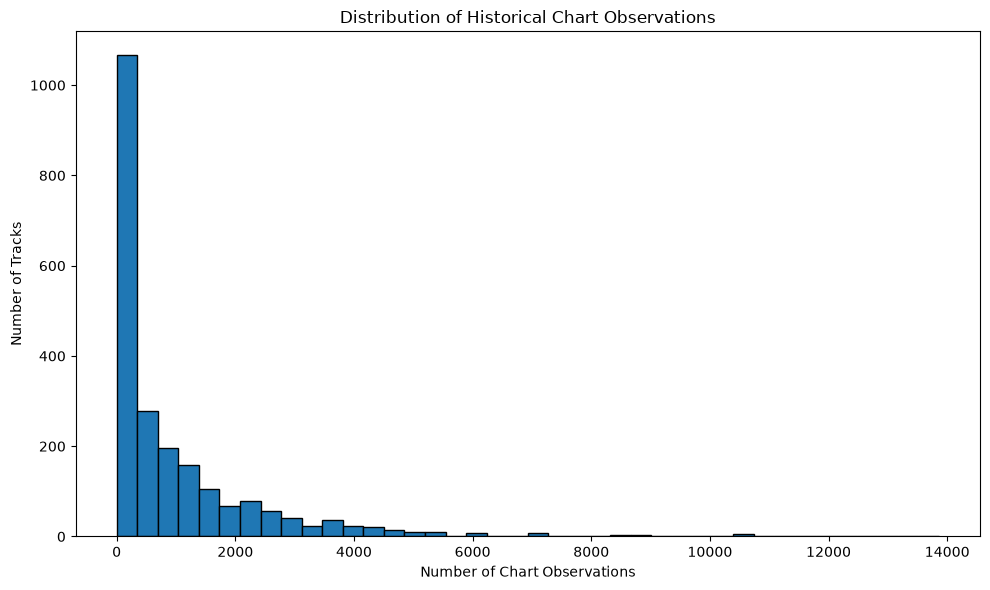

In [27]:
# Visualise the distribution of historical chart observations

plt.figure(figsize=(10, 6))

plt.hist(
    chart_observations,
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Historical Chart Observations")
plt.xlabel("Number of Chart Observations")
plt.ylabel("Number of Tracks")

plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

### Interpretation

The distribution of historical chart observations is strongly right-skewed. Most tracks have relatively few chart observations, while a smaller number of tracks have substantially higher observation counts, creating a long tail that extends to 13,860 observations.

The median number of chart observations is 409, compared with a considerably higher mean of approximately 1,023. This difference confirms that tracks with very high observation counts are pulling the average upward. Of the 2,235 tracks with historical chart data, 1,565 have at least 100 observations, 715 have at least 1,000 observations, while only 60 have at least 5,000 observations.

This variation suggests that tracks differ considerably in the frequency with which they appeared within the historical chart dataset. Tracks with larger observation counts may represent releases with greater chart persistence, broader geographic exposure, or both. However, observation frequency should not be interpreted as chart success on its own because a track could appear frequently without consistently achieving high chart positions.

For PMIP, `chart_observations` may therefore provide a useful indicator of historical chart persistence when combined with features such as `best_chart_position`, `average_chart_position`, `countries_charted` and historical streaming performance.

## 6.4 Historical Chart Streams

This section examines the historical streaming performance of tracks within the integrated dataset. Three measures are considered: total historical streams, average historical streams per chart observation and maximum historical streams recorded for a track.

Analysing these measures provides additional information about the scale and intensity of historical streaming performance. Total streams represent accumulated historical streaming activity, while average and maximum streams provide different perspectives on typical and peak performance.

In [28]:
# Select historical streaming performance metrics

historical_stream_metrics = [
    "total_historical_streams",
    "average_historical_streams",
    "max_historical_streams"
]

# Calculate descriptive statistics
historical_stream_summary = df[historical_stream_metrics].describe().T

historical_stream_summary

,count,mean,std,min,25%,50%,75%,max
total_historical_streams,"2,235.00","419,984,430.43","645,357,916.00","1,904.00","32,887,104.00","171,706,002.00","534,224,802.50","6,226,855,629.00"
average_historical_streams,"2,235.00","585,288.93","578,920.57","1,560.00","237,524.18","440,868.67","718,015.15","6,320,841.50"
max_historical_streams,"2,235.00","11,814,935.81","12,924,714.55","1,560.00","2,425,893.00","8,020,928.00","16,480,270.00","115,156,896.00"


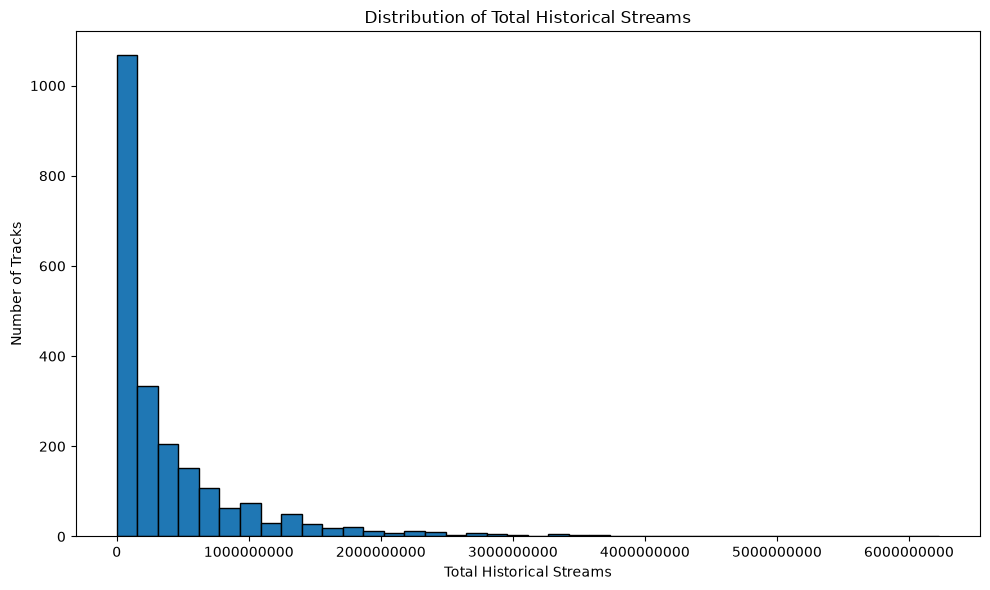

In [29]:
# Prepare non-missing total historical stream observations
total_historical_streams = df["total_historical_streams"].dropna()

# Plot the distribution of total historical streams
plt.figure(figsize=(10, 6))

plt.hist(
    total_historical_streams,
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Total Historical Streams")
plt.xlabel("Total Historical Streams")
plt.ylabel("Number of Tracks")

plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

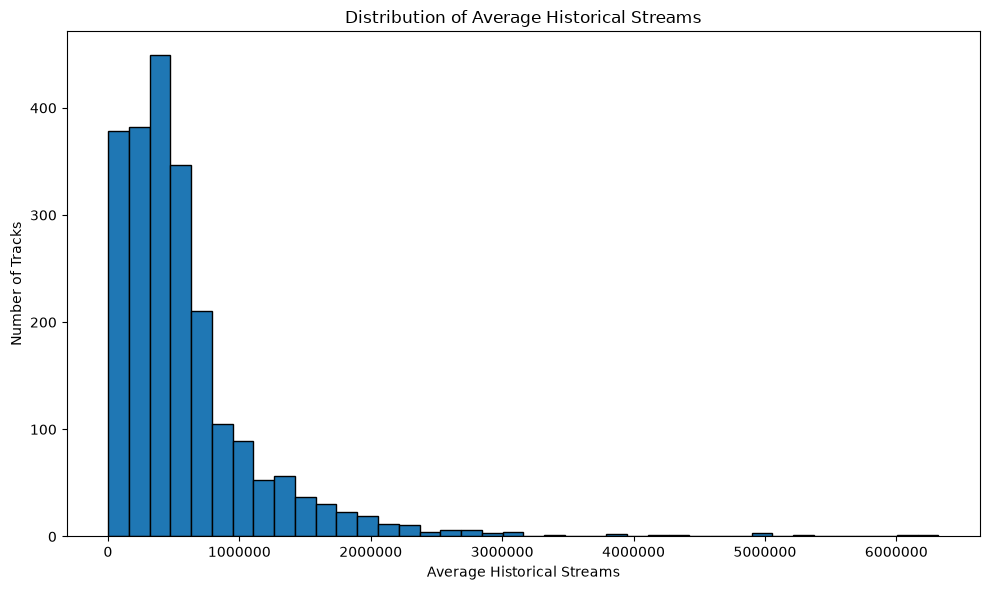

In [30]:
# Prepare non-missing average historical stream observations
average_historical_streams = df["average_historical_streams"].dropna()

# Plot the distribution of average historical streams
plt.figure(figsize=(10, 6))

plt.hist(
    average_historical_streams,
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Average Historical Streams")
plt.xlabel("Average Historical Streams")
plt.ylabel("Number of Tracks")

plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

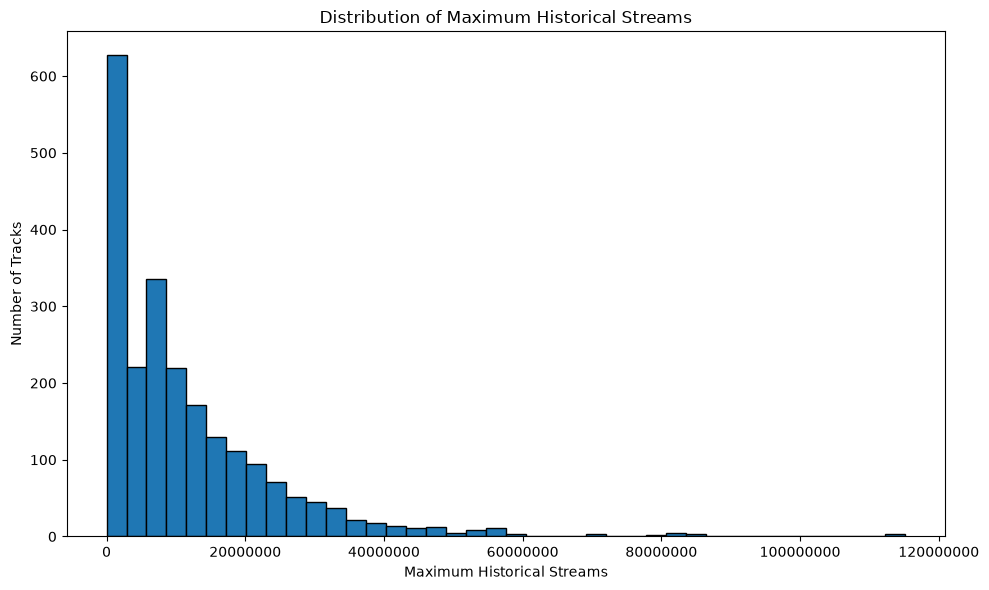

In [31]:
# Prepare non-missing maximum historical stream observations
max_historical_streams = df["max_historical_streams"].dropna()

# Plot the distribution of maximum historical streams
plt.figure(figsize=(10, 6))

plt.hist(
    max_historical_streams,
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Maximum Historical Streams")
plt.xlabel("Maximum Historical Streams")
plt.ylabel("Number of Tracks")

plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

### Interpretation

The historical streaming metrics show substantial differences in performance across the tracks with available historical chart data.

Total historical streams are strongly right-skewed. Most tracks accumulated relatively lower historical streaming totals, while a much smaller number achieved exceptionally large totals. The median total historical streams was approximately 171.7 million, compared with a mean of approximately 420.0 million, with the highest value reaching approximately 6.23 billion. The large difference between the mean and median reflects the influence of a relatively small number of extremely high-performing tracks.

Average historical streams show a similar pattern. The median was approximately 440,869 streams, while the mean was approximately 585,289. Most tracks were concentrated toward the lower end of the distribution, although a smaller group recorded substantially higher average streaming activity, with the maximum reaching approximately 6.32 million.

Maximum historical streams were also strongly right-skewed. The median maximum was approximately 8.02 million streams, compared with a mean of approximately 11.81 million, while the highest recorded value was approximately 115.16 million. This indicates that some tracks experienced substantially larger peak streaming observations than the majority of tracks.

Overall, the three distributions demonstrate that historical streaming performance is highly uneven across the dataset. A relatively small number of tracks account for extremely high levels of streaming activity, while most tracks occupy considerably lower performance ranges. These highly skewed variables and extreme observations should therefore be considered carefully during later correlation analysis, feature engineering and machine-learning development, where transformations such as logarithmic scaling may be useful.

# 7 — Feature Relationship Analysis

This section investigates relationships between important performance variables within the integrated PMIP dataset. The aim is to determine whether Spotify performance, artist audience size and historical chart performance show meaningful associations that may later support feature engineering and machine-learning development.

## 7.1 Spotify Streams vs Spotify Popularity

In [32]:
# Select Spotify Streams and Spotify Popularity
spotify_streams_popularity = df[
    ["Spotify Streams", "Spotify Popularity"]
].dropna()

print(f"Complete observations: {len(spotify_streams_popularity):,}")

# Calculate Pearson correlation
streams_popularity_correlation = (
    spotify_streams_popularity["Spotify Streams"]
    .corr(spotify_streams_popularity["Spotify Popularity"])
)

print(
    f"Pearson correlation: "
    f"{streams_popularity_correlation:.3f}"
)

# Display descriptive statistics
spotify_streams_popularity.describe()

Complete observations: 3,779
Pearson correlation: 0.360


,Spotify Streams,Spotify Popularity
count,"3,779.00","3,779.00"
mean,"493,377,640.75",63.70
std,"539,915,440.08",15.88
min,"2,030.00",1.00
25%,"110,412,455.00",61.00
50%,"305,231,016.00",67.00
75%,"689,975,074.50",73.00
max,"4,281,468,720.00",96.00


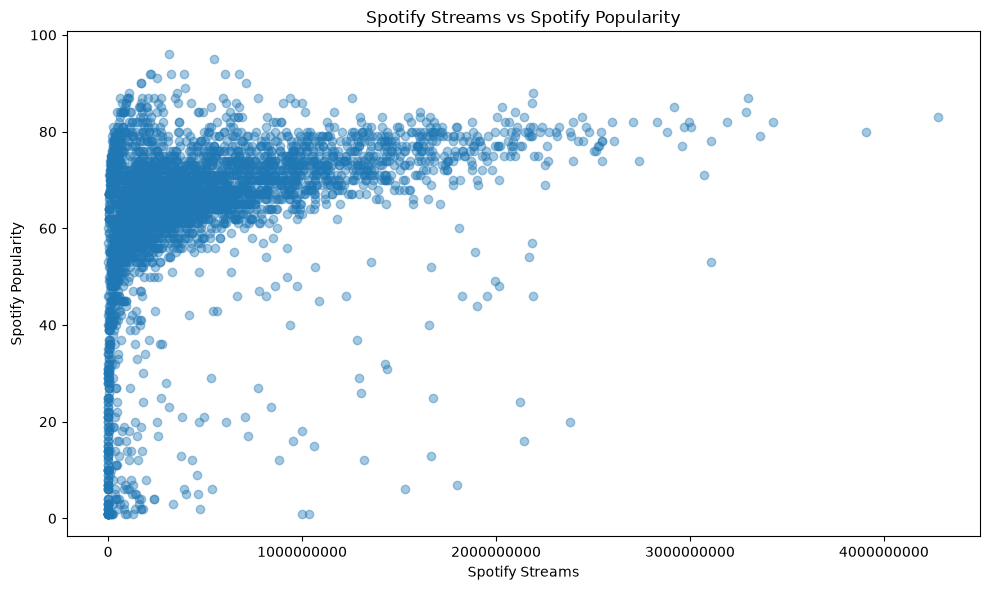

In [33]:
# Visualise the relationship between Spotify Streams and Spotify Popularity
plt.figure(figsize=(10, 6))

plt.scatter(
    spotify_streams_popularity["Spotify Streams"],
    spotify_streams_popularity["Spotify Popularity"],
    alpha=0.4
)

plt.title("Spotify Streams vs Spotify Popularity")
plt.xlabel("Spotify Streams")
plt.ylabel("Spotify Popularity")

plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

### Interpretation

The scatter plot shows a positive relationship between Spotify Streams and Spotify Popularity, which is consistent with the Pearson correlation coefficient of **0.360** calculated from **3,779 complete observations**.

Tracks with lower streaming totals show a wide range of popularity scores, including both very low and relatively high popularity. As streaming totals increase, the observations become more concentrated around higher popularity scores, particularly between approximately 60 and 80.

However, the points do not form a strong linear pattern. Some tracks with relatively high streaming totals have noticeably lower popularity scores, while some tracks with fewer streams have high popularity scores. This indicates that streaming totals alone do not fully explain Spotify Popularity.

The relationship can therefore be described as a **moderate positive association rather than a strong relationship**. This suggests that Spotify Streams may be a useful predictive feature in later PMIP modelling, but it should be considered alongside other performance indicators rather than being used independently.

The wide spread among lower-streamed tracks and the presence of several unusual observations should also be considered during later outlier analysis and feature engineering.

### 7.2 Spotify Streams vs Track Score

This section examines the relationship between a track's Spotify streaming performance and its overall Track Score.

The analysis uses complete observations for both variables and calculates the Pearson correlation coefficient to measure the strength and direction of their linear relationship.

In [34]:
# Select Spotify Streams and Track Score
streams_score = df[
    ["Spotify Streams", "Track Score"]
].dropna()

# Calculate Pearson correlation
streams_score_correlation = streams_score[
    "Spotify Streams"
].corr(streams_score["Track Score"])

# Display number of complete observations and correlation
print(f"Complete observations: {len(streams_score):,}")
print(f"Pearson correlation: {streams_score_correlation:.3f}")

# Display descriptive statistics
streams_score.describe().T

Complete observations: 4,485
Pearson correlation: 0.251


,count,mean,std,min,25%,50%,75%,max
Spotify Streams,"4,485.00","447,406,866.92","538,550,400.79","1,071.00","70,354,552.00","239,850,720.00","629,102,459.00","4,281,468,720.00"
Track Score,"4,485.00",41.77,38.54,19.40,23.30,29.90,44.40,725.40


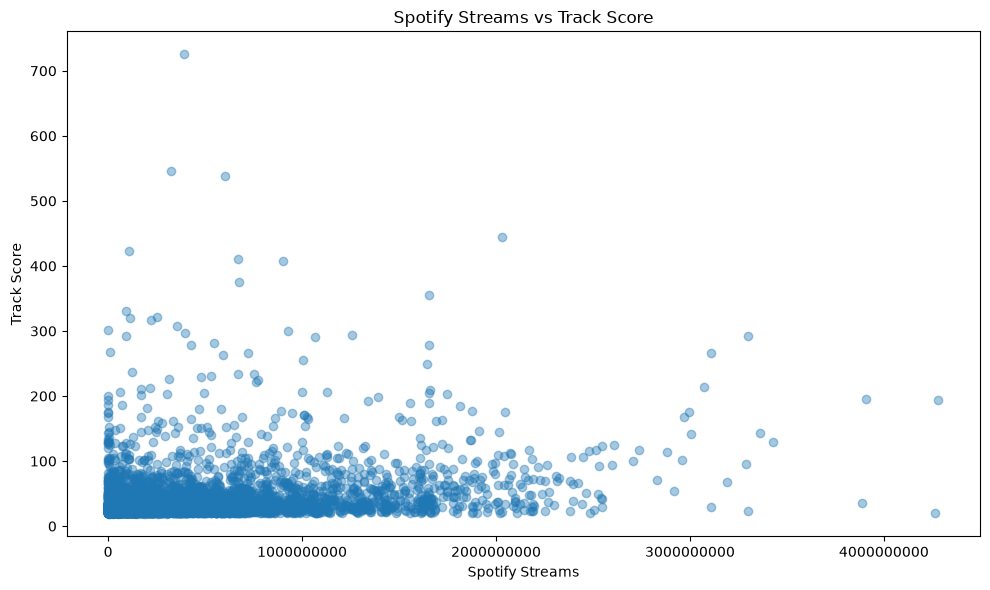

In [35]:
# Visualise the relationship between Spotify Streams and Track Score
plt.figure(figsize=(10, 6))

plt.scatter(
    streams_score["Spotify Streams"],
    streams_score["Track Score"],
    alpha=0.4
)

plt.title("Spotify Streams vs Track Score")
plt.xlabel("Spotify Streams")
plt.ylabel("Track Score")

# Display Spotify Streams without scientific notation
plt.ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()

### Interpretation

The analysis shows a **weak positive relationship** between Spotify Streams and Track Score. Across **4,485 complete observations**, the Pearson correlation coefficient is **0.251**, indicating that tracks with higher Spotify streaming totals tend to have somewhat higher Track Scores, but the relationship is not strong.

The scatter plot supports this result. Most tracks are concentrated at relatively lower Track Score values, while Spotify Streams vary considerably across these observations. This indicates that tracks with similar Track Scores can have very different streaming totals.

Several unusually high Track Score observations are also visible, particularly among tracks with lower to moderate Spotify streaming totals. The maximum Track Score is **725.4**, compared with a median of only **29.9**, showing that the variable contains substantial extreme values. These observations may influence the correlation and should therefore be examined during the later outlier analysis.

Overall, Spotify Streams appear to provide some information about Track Score, but streaming performance alone does not explain the substantial variation in Track Score. This suggests that other platform and performance metrics may also contribute to the score and should be considered during later feature engineering and modelling.

### 7.3 Artist Listeners vs Spotify Streams

This section examines the relationship between an artist's listener audience and the Spotify streaming performance of tracks associated with that artist.

The analysis uses complete observations for both variables and calculates the Pearson correlation coefficient to measure the strength and direction of their linear relationship.

In [36]:
# Select Artist Listeners and Spotify Streams
listeners_streams = df[
    ["Listeners", "Spotify Streams"]
].dropna()

# Calculate Pearson correlation
listeners_streams_correlation = listeners_streams[
    "Listeners"
].corr(listeners_streams["Spotify Streams"])

# Display number of complete observations and correlation
print(f"Complete observations: {len(listeners_streams):,}")
print(f"Pearson correlation: {listeners_streams_correlation:.3f}")

# Display descriptive statistics
listeners_streams.describe().T

Complete observations: 3,360
Pearson correlation: 0.300


,count,mean,std,min,25%,50%,75%,max
Listeners,"3,360.00","31,142,019.57","24,296,181.93","4,281,434.00","11,179,501.75","23,976,058.00","46,559,302.00","107,592,328.00"
Spotify Streams,"3,360.00","540,019,027.97","558,492,517.90","3,369.00","136,574,301.25","353,956,782.00","760,320,874.75","4,281,468,720.00"


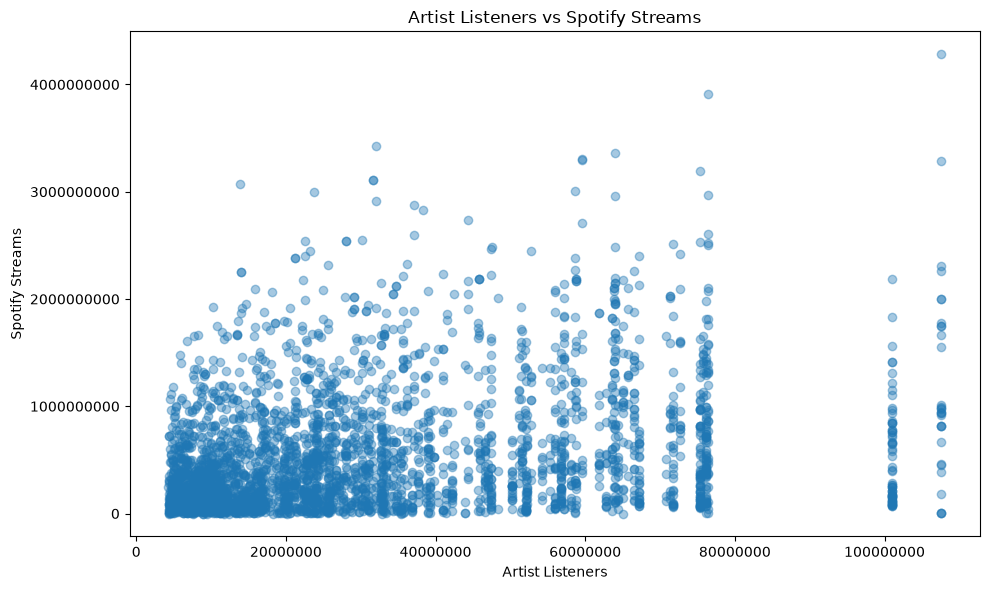

In [37]:
# Visualise Artist Listeners vs Spotify Streams
plt.figure(figsize=(10, 6))

plt.scatter(
    listeners_streams["Listeners"],
    listeners_streams["Spotify Streams"],
    alpha=0.4
)

plt.title("Artist Listeners vs Spotify Streams")
plt.xlabel("Artist Listeners")
plt.ylabel("Spotify Streams")

plt.ticklabel_format(style="plain", axis="both")

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot indicates a positive but relatively weak-to-moderate relationship between artist listener count and Spotify track streams. This is supported by the Pearson correlation coefficient of 0.300.

Although artists with larger listener audiences can achieve higher track streaming totals, there is substantial variation across the dataset. Tracks belonging to artists with similar listener counts can have very different streaming totals, while some artists with large audiences also have tracks with comparatively low stream counts.

An important consideration is that listener count represents an artist-level characteristic, whereas Spotify Streams represents the performance of an individual track. Therefore, artist audience size provides useful contextual information but does not independently explain track-level streaming performance.

For PMIP, artist listener count may therefore be useful as one predictive feature alongside track-level popularity, historical chart performance and other performance indicators.

### 7.4 Historical Performance vs Current Performance

This section investigates the relationship between historical streaming performance and current Spotify streaming performance. The analysis helps determine whether tracks with stronger historical performance also tend to demonstrate stronger current streaming performance.

In [38]:
# Select current Spotify Streams and historical streaming performance
historical_current = df[
    ["Spotify Streams", "total_historical_streams"]
].dropna()

# Calculate Pearson correlation
historical_current_correlation = historical_current[
    "Spotify Streams"
].corr(historical_current["total_historical_streams"])

# Display number of complete observations and correlation
print(f"Complete observations: {len(historical_current):,}")
print(f"Pearson correlation: {historical_current_correlation:.3f}")

# Display descriptive statistics
historical_current.describe().T

Complete observations: 2,220
Pearson correlation: 0.805


,count,mean,std,min,25%,50%,75%,max
Spotify Streams,"2,220.00","694,233,051.36","583,433,393.18","16,119.00","260,951,284.75","520,873,724.50","959,137,478.00","4,281,468,720.00"
total_historical_streams,"2,220.00","416,661,718.80","644,592,592.59","1,904.00","32,623,360.25","167,400,895.50","531,142,441.00","6,226,855,629.00"


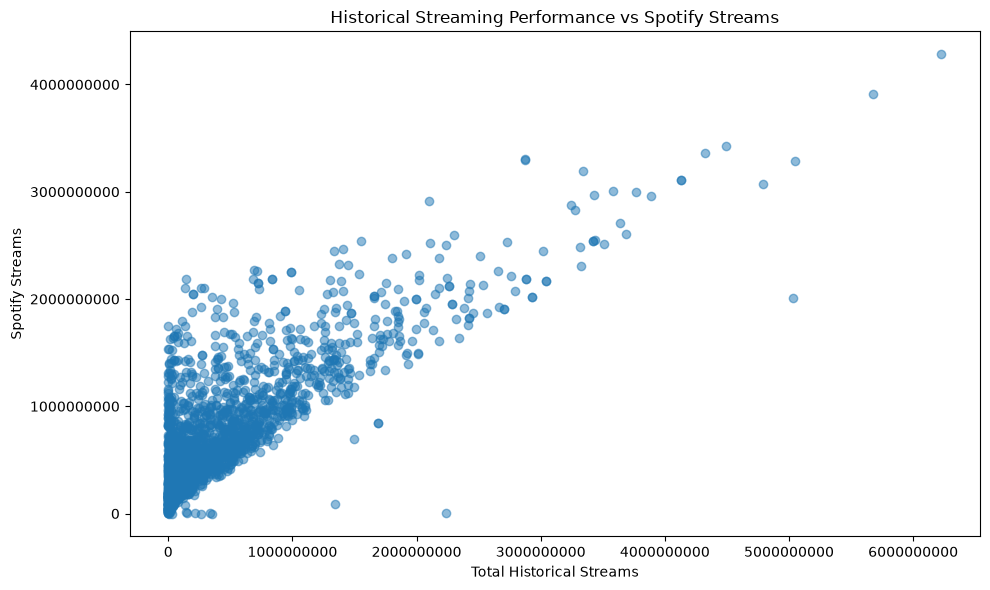

In [39]:
# Plot historical streaming performance against current Spotify Streams
plt.figure(figsize=(10, 6))

plt.scatter(
    historical_current["total_historical_streams"],
    historical_current["Spotify Streams"],
    alpha=0.5
)

plt.title("Historical Streaming Performance vs Spotify Streams")
plt.xlabel("Total Historical Streams")
plt.ylabel("Spotify Streams")

plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()

### Interpretation

The analysis shows a strong positive relationship between total historical streaming performance and Spotify Streams, with a Pearson correlation coefficient of 0.805.

The scatter plot supports this result by showing a clear upward pattern. Tracks with higher total historical streams generally also have higher Spotify streaming totals. Although some variation and unusual observations remain, the relationship is substantially stronger than the relationships observed between Spotify Streams and Spotify Popularity, Track Score, or artist listener count.

This suggests that historical streaming performance contains valuable information about the broader streaming success of a track. Historical performance variables may therefore be particularly useful features during later PMIP feature engineering and machine-learning development.

However, correlation does not establish causation, and total historical streams may also be influenced by factors such as the length of time a track remained on the charts, its geographic reach and the number of chart observations. These related variables should therefore be investigated further before selecting features for predictive modelling.

## 8. Correlation Analysis

This section examines correlations between important numerical variables within the integrated PMIP dataset. The analysis provides a broader understanding of relationships between current streaming performance, platform metrics, artist audience characteristics and historical chart performance.

### 8.1 Correlation Matrix

A correlation matrix is used to compare multiple numerical performance variables simultaneously and identify potentially strong positive or negative relationships.

In [40]:
# Selecting important numerical variables for correlation analysis
correlation_features = [
    "Spotify Streams",
    "Spotify Popularity",
    "Track Score",
    "Listeners",
    "Daily Trend",
    "Peak",
    "PkListeners",
    "best_chart_position",
    "average_chart_position",
    "chart_observations",
    "countries_charted",
    "total_historical_streams",
    "average_historical_streams",
    "max_historical_streams"
]

# Create correlation dataset
correlation_data = df[correlation_features]

# Calculate Pearson correlation matrix
correlation_matrix = correlation_data.corr()

# Display matrix rounded to three decimal places
correlation_matrix.round(3)

,Spotify Streams,Spotify Popularity,Track Score,Listeners,Daily Trend,Peak,PkListeners,best_chart_position,average_chart_position,chart_observations,countries_charted,total_historical_streams,average_historical_streams,max_historical_streams
Spotify Streams,1.00,0.36,0.25,0.30,0.02,-0.28,0.30,-0.23,-0.08,0.79,0.67,0.81,-0.11,0.55
Spotify Popularity,0.36,1.00,0.19,0.18,-0.03,-0.15,0.18,-0.12,-0.01,0.24,0.26,0.24,-0.01,0.21
Track Score,0.25,0.19,1.00,0.15,-0.01,-0.12,0.16,-0.15,-0.23,0.31,0.33,0.49,0.15,0.50
Listeners,0.30,0.18,0.15,1.00,-0.11,-0.67,0.99,-0.17,-0.12,0.27,0.45,0.31,-0.07,0.46
Daily Trend,0.02,-0.03,-0.01,-0.11,1.00,0.04,-0.14,0.04,0.07,0.00,0.05,0.01,0.01,0.01
Peak,-0.28,-0.15,-0.12,-0.67,0.04,1.00,-0.68,0.17,0.07,-0.21,-0.36,-0.24,0.05,-0.32
PkListeners,0.30,0.18,0.16,0.99,-0.14,-0.68,1.00,-0.18,-0.13,0.27,0.46,0.31,-0.06,0.47
best_chart_position,-0.23,-0.12,-0.15,-0.17,0.04,0.17,-0.18,1.00,0.74,-0.31,-0.51,-0.32,-0.07,-0.41
average_chart_position,-0.08,-0.01,-0.23,-0.12,0.07,0.07,-0.13,0.74,1.00,-0.19,-0.28,-0.29,-0.30,-0.43
chart_observations,0.79,0.24,0.31,0.27,0.00,-0.21,0.27,-0.31,-0.19,1.00,0.65,0.84,-0.20,0.42


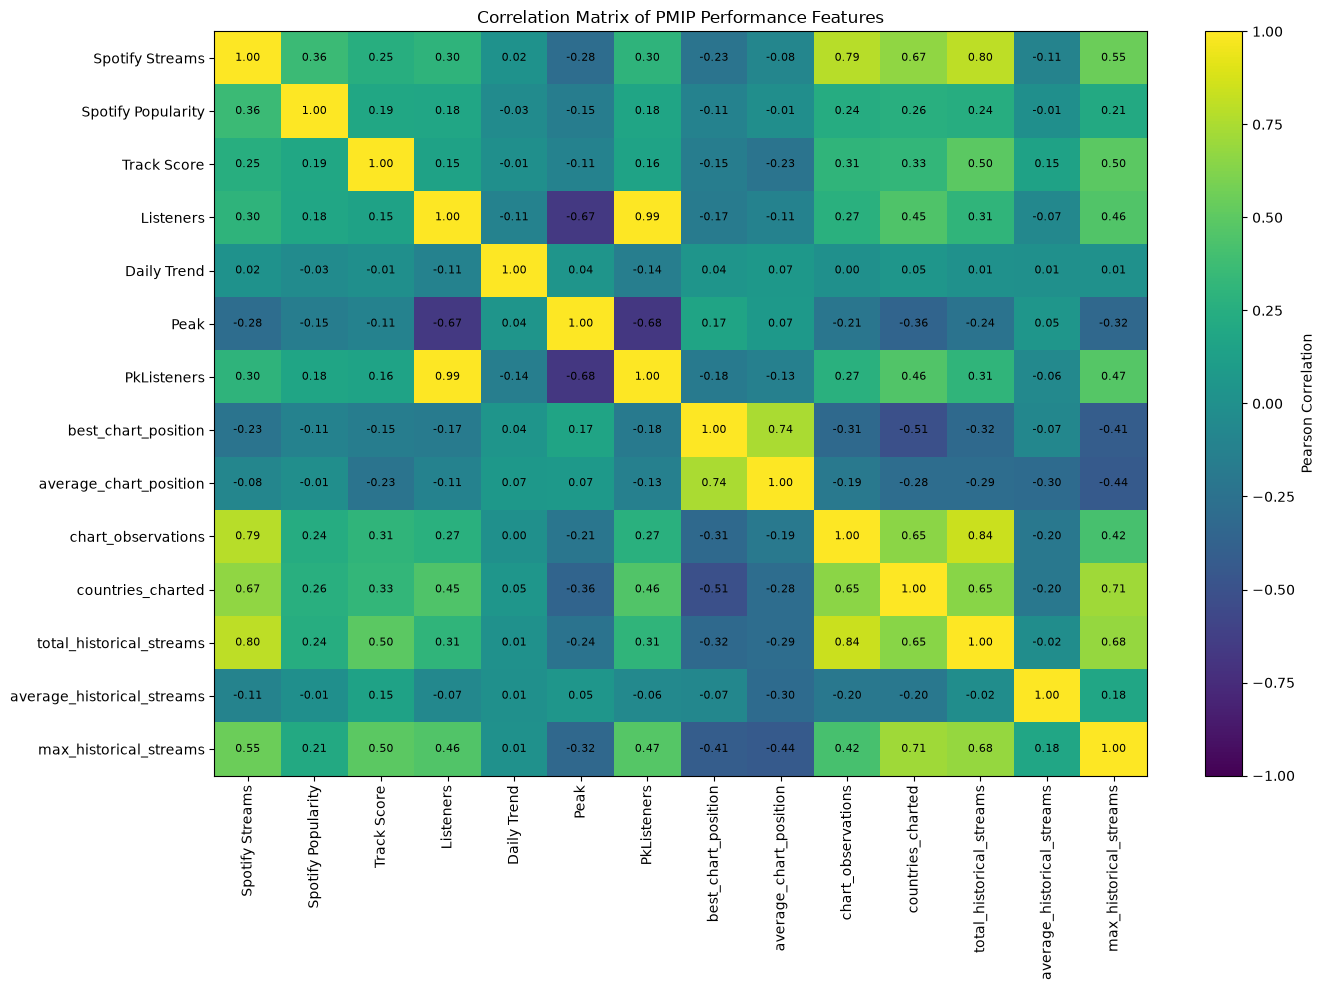

In [42]:
# Visualise the correlation matrix
plt.figure(figsize=(14, 10))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Pearson Correlation")

# Add feature labels
plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=90
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

# Add correlation values inside each cell
for i in range(len(correlation_features)):
    for j in range(len(correlation_features)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix of PMIP Performance Features")
plt.tight_layout()
plt.show()

### Interpretation

The correlation matrix shows several important relationships between the performance features in the integrated PMIP dataset.

One of the strongest positive relationships is between `Listeners` and `PkListeners`, with a correlation of approximately **0.99**. This indicates that artists with larger listener audiences also tend to have higher peak listener values. Because these variables contain very similar information, their strong relationship may need to be considered during feature engineering to avoid unnecessary feature redundancy.

Strong relationships are also visible among the historical performance variables. `chart_observations` and `total_historical_streams` have a correlation of approximately **0.84**, while `Spotify Streams` and `total_historical_streams` have a correlation of approximately **0.80**. This suggests that tracks with stronger historical chart and streaming performance also tend to have higher current Spotify streaming totals.

Geographic reach also appears important. `countries_charted` has positive relationships with `max_historical_streams` (**0.71**), `Spotify Streams` (**0.67**) and `total_historical_streams` (**0.65**). This suggests that tracks performing across a wider range of countries are generally associated with stronger streaming performance.

Several negative relationships are also visible. `Peak` has strong negative relationships with `Listeners` (**-0.67**) and `PkListeners` (**-0.68**). This should be interpreted carefully because lower numerical chart positions represent better performance. Similarly, `best_chart_position` is negatively related to `countries_charted` (**-0.51**), meaning tracks achieving better chart positions tend to appear across more countries.

`Daily Trend` shows correlations close to zero with most variables, suggesting that short-term movement may capture a different aspect of performance from the cumulative streaming and historical variables.

Overall, the matrix indicates that historical streaming performance, chart persistence and geographic reach may provide useful information for later PMIP modelling. However, the presence of highly correlated variables also suggests that feature redundancy and multicollinearity should be investigated during feature engineering. Correlation represents association rather than causation.

### 8.2 Strongest Positive Relationships

This section identifies and ranks the strongest positive correlations between the numerical performance features in the integrated PMIP dataset.

Only unique feature pairs are considered so that duplicate relationships and self-correlations are excluded.

In [45]:
# Extract unique correlation pairs from the correlation matrix

positive_relationships = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        feature_1 = correlation_matrix.columns[i]
        feature_2 = correlation_matrix.columns[j]
        correlation = correlation_matrix.iloc[i, j]

        # Keep only positive correlations
        if correlation > 0:
            positive_relationships.append(
                {
                    "Feature 1": feature_1,
                    "Feature 2": feature_2,
                    "Correlation": correlation
                }
            )

# Convert the relationships into a DataFrame
positive_relationships_df = pd.DataFrame(positive_relationships)

# Sort from strongest to weakest positive correlation
positive_relationships_df = (
    positive_relationships_df
    .sort_values("Correlation", ascending=False)
    .reset_index(drop=True)
)

# Display the 15 strongest positive relationships
positive_relationships_df.head(15).style.format(
    {"Correlation": "{:.3f}"}
)

,Feature 1,Feature 2,Correlation
0,Listeners,PkListeners,0.993
1,chart_observations,total_historical_streams,0.837
2,Spotify Streams,total_historical_streams,0.805
3,Spotify Streams,chart_observations,0.788
4,best_chart_position,average_chart_position,0.744
5,countries_charted,max_historical_streams,0.713
6,total_historical_streams,max_historical_streams,0.680
7,Spotify Streams,countries_charted,0.669
8,chart_observations,countries_charted,0.649
9,countries_charted,total_historical_streams,0.646


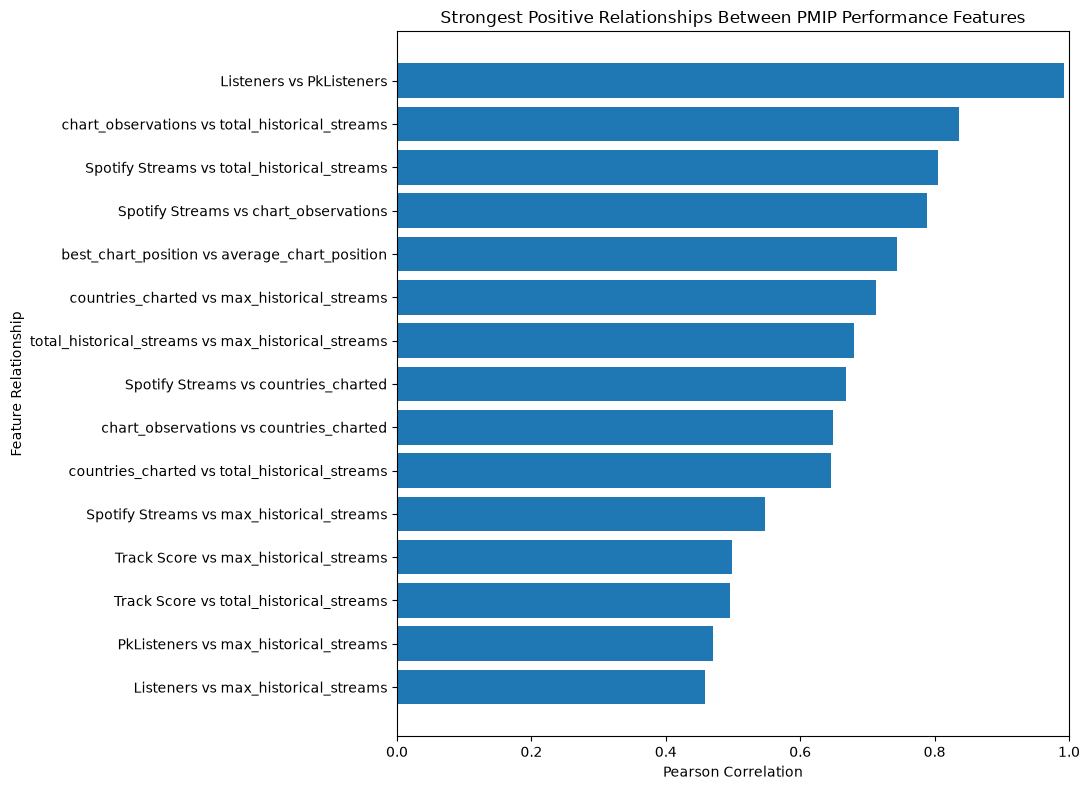

In [46]:
# Selecting the 15 strongest positive relationships for visualisation
top_positive = positive_relationships_df.head(15).copy()

# Create readable relationship labels
top_positive["Relationship"] = (
    top_positive["Feature 1"] + " vs " + top_positive["Feature 2"]
)

# Sort so the strongest relationship appears at the top
top_positive = top_positive.sort_values("Correlation", ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(11, 8))

plt.barh(
    top_positive["Relationship"],
    top_positive["Correlation"]
)

plt.title("Strongest Positive Relationships Between PMIP Performance Features")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature Relationship")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

### Interpretation

The strongest positive correlation is between `Listeners` and `PkListeners`
(r = 0.993), indicating that these two artist audience measures contain very
similar information. This suggests that the variables may provide redundant
information and should be reviewed during feature engineering before they are
used together in a machine-learning model.

Historical performance also shows strong relationships with current streaming
performance. `chart_observations` and `total_historical_streams` have a strong
positive correlation (r = 0.837), while `Spotify Streams` are strongly
associated with both `total_historical_streams` (r = 0.805) and
`chart_observations` (r = 0.788). This suggests that tracks with stronger and
more persistent historical chart activity generally also have higher current
Spotify streaming totals.

Geographic reach is another important pattern. `countries_charted` is
positively associated with `max_historical_streams` (r = 0.713), `Spotify
Streams` (r = 0.669), `chart_observations` (r = 0.649) and
`total_historical_streams` (r = 0.646). This indicates that tracks reaching
more geographic markets also tend to demonstrate stronger overall streaming
and chart performance.

The results therefore suggest that historical streaming performance, chart
persistence and geographic reach may provide useful information for later PMIP
feature engineering and predictive modelling. However, highly correlated
features should be reviewed carefully to avoid unnecessary redundancy.

### 8.3 Strongest Negative Relationships

This section identifies the strongest negative correlations between the numerical
performance features in the PMIP dataset. A negative correlation indicates that
as one variable increases, the other tends to decrease.

The analysis ranks the negative relationships by their Pearson correlation
coefficients and visualises the strongest relationships for easier comparison.

Particular care is required when interpreting ranking variables such as
`best_chart_position` and `Peak`, because lower numerical values represent
stronger ranking performance. Therefore, a negative correlation involving these
variables does not necessarily represent a negative performance relationship.

In [ ]:
# Extracting unique negative correlation pairs from the correlation matrix
negative_relationships = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        
        feature_1 = correlation_matrix.columns[i]
        feature_2 = correlation_matrix.columns[j]
        correlation = correlation_matrix.iloc[i, j]
        
        # Keep only negative relationships
        if correlation < 0:
            negative_relationships.append(
                {
                    "Feature 1": feature_1,
                    "Feature 2": feature_2,
                    "Correlation": correlation
                }
            )

# Convert the relationships into a DataFrame
negative_relationships_df = pd.DataFrame(negative_relationships)

# Sort from strongest negative relationship upwards
negative_relationships_df = (
    negative_relationships_df
    .sort_values("Correlation", ascending=True)
    .reset_index(drop=True)
)

# Display the 15 strongest negative relationships
negative_relationships_df.head(15).style.format(
    {"Correlation": "{:.3f}"}
)

,Feature 1,Feature 2,Correlation
0,Peak,PkListeners,-0.677
1,Listeners,Peak,-0.665
2,best_chart_position,countries_charted,-0.509
3,average_chart_position,max_historical_streams,-0.435
4,best_chart_position,max_historical_streams,-0.407
5,Peak,countries_charted,-0.357
6,Peak,max_historical_streams,-0.323
7,best_chart_position,total_historical_streams,-0.320
8,best_chart_position,chart_observations,-0.314
9,average_chart_position,average_historical_streams,-0.297


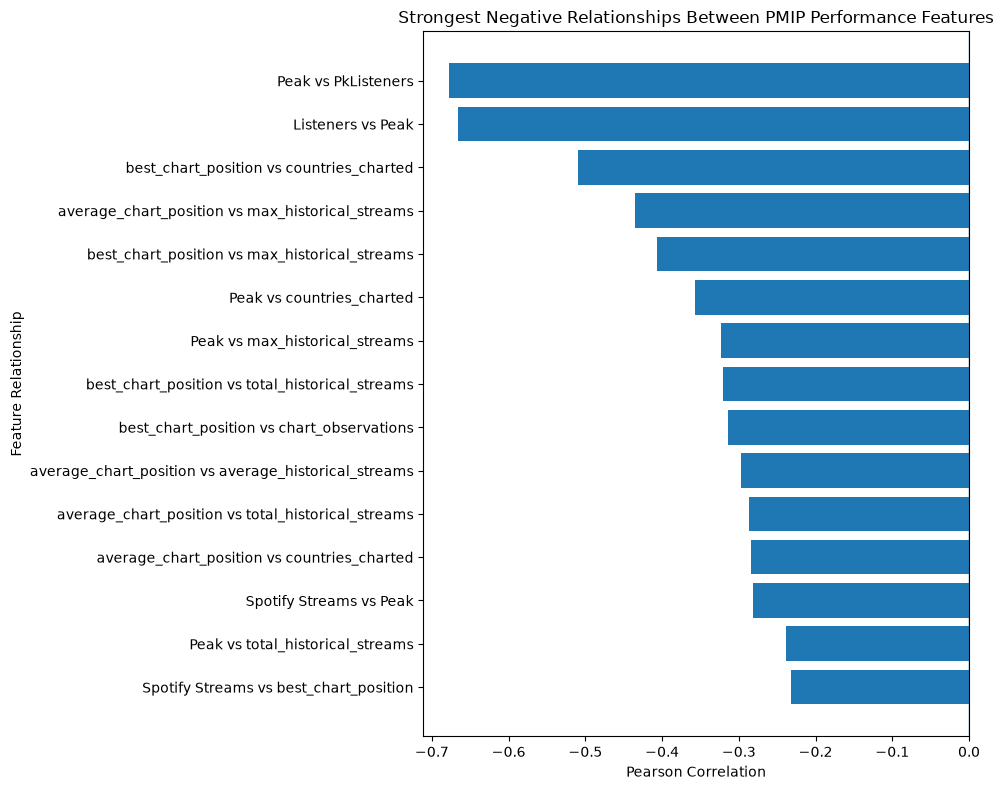

In [48]:
# Creating readable labels for each negative feature relationship
negative_plot = negative_relationships_df.head(15).copy()

negative_plot["Relationship"] = (
    negative_plot["Feature 1"]
    + " vs "
    + negative_plot["Feature 2"]
)

# Sort relationships for horizontal bar chart
negative_plot = negative_plot.sort_values(
    "Correlation",
    ascending=False
)

# Visualise the strongest negative correlations
plt.figure(figsize=(10, 8))

plt.barh(
    negative_plot["Relationship"],
    negative_plot["Correlation"]
)

plt.title(
    "Strongest Negative Relationships Between PMIP Performance Features"
)

plt.xlabel("Pearson Correlation")
plt.ylabel("Feature Relationship")

# Add a reference line showing zero correlation
plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

### Interpretation of Strongest Negative Relationships

The correlation analysis identified several moderate to strong negative relationships between PMIP performance features.

The strongest negative relationship was between `Peak` and `PkListeners` (r = -0.677), followed by `Listeners` and `Peak` (r = -0.665). Since a lower peak ranking represents a better chart position, these relationships suggest that artists with larger listener audiences tend to achieve better peak rankings.

A similar pattern can be observed for historical chart performance. `best_chart_position` and `countries_charted` showed a moderate negative correlation (r = -0.509). This suggests that tracks achieving better historical chart positions also tend to appear across a larger number of countries.

Historical streaming performance also showed negative relationships with chart-position variables. `average_chart_position` was negatively related to `max_historical_streams` (r = -0.435), while `best_chart_position` was negatively related to `max_historical_streams` (r = -0.407). This indicates that stronger historical streaming performance tends to be associated with better chart rankings.

These findings demonstrate an important characteristic of ranking variables within the dataset: negative correlations involving chart positions do not necessarily represent negative performance. Because smaller ranking values indicate better performance, a negative relationship between a ranking variable and a performance metric can represent a meaningful positive association in practical terms.

This distinction should be considered during feature engineering and machine-learning development, particularly when interpreting chart-position features.

## 9. Outlier Analysis

This section investigates unusually high or low observations within the main PMIP performance variables.

Outliers may represent genuine high-performing artists and tracks rather than data errors. Therefore, the purpose of this analysis is to identify and understand extreme observations before deciding how they should be handled during feature engineering and machine-learning development.

The analysis focuses on streaming performance, artist listener statistics and historical chart performance.

### 9.1 Streaming Outliers

This subsection investigates extreme values within Spotify streaming performance. The interquartile range (IQR) method is used to identify observations that fall substantially above or below the typical range of Spotify Streams values.

The identified observations are examined rather than automatically removed, as extremely high streaming values may represent genuinely successful tracks.

In [49]:
# Select Spotify streaming values
spotify_streams = df["Spotify Streams"].dropna()

# Calculate the first and third quartiles
q1 = spotify_streams.quantile(0.25)
q3 = spotify_streams.quantile(0.75)

# Calculate the interquartile range
iqr = q3 - q1

# Define IQR outlier boundaries
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

# Identify streaming outliers
streaming_outliers = df[
    (df["Spotify Streams"] < lower_bound)
    | (df["Spotify Streams"] > upper_bound)
].copy()

# Display results
print(f"Q1: {q1:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Lower outlier boundary: {lower_bound:,.2f}")
print(f"Upper outlier boundary: {upper_bound:,.2f}")

print(f"\nTotal observations analysed: {len(spotify_streams):,}")
print(f"Streaming outliers detected: {len(streaming_outliers):,}")
print(
    f"Percentage identified as outliers: "
    f"{len(streaming_outliers) / len(spotify_streams) * 100:.2f}%"
)

Q1: 70,354,552.00
Q3: 629,102,459.00
IQR: 558,747,907.00
Lower outlier boundary: -767,767,308.50
Upper outlier boundary: 1,467,224,319.50

Total observations analysed: 4,485
Streaming outliers detected: 289
Percentage identified as outliers: 6.44%


/var/folders/8w/59s2t7hd74g4f203_5w8w38r0000gp/T/ipykernel_88744/3050910927.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


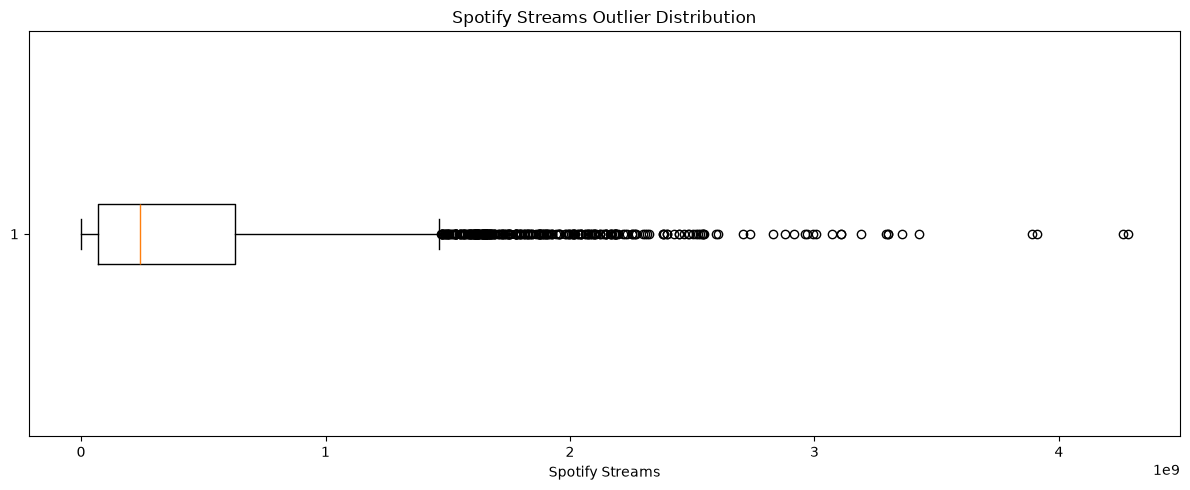

In [50]:
# Visualise Spotify streaming outliers

plt.figure(figsize=(12, 5))

plt.boxplot(
    spotify_streams,
    vert=False
)

plt.title("Spotify Streams Outlier Distribution")
plt.xlabel("Spotify Streams")

plt.tight_layout()
plt.show()

In [51]:
# Inspect the highest Spotify streaming outliers

top_streaming_outliers = (
    streaming_outliers[
        ["Track", "Artist", "Spotify Streams", "Spotify Popularity", "Track Score"]
    ]
    .sort_values("Spotify Streams", ascending=False)
    .head(15)
)

top_streaming_outliers.style.format({
    "Spotify Streams": "{:,.0f}",
    "Spotify Popularity": "{:.0f}",
    "Track Score": "{:.2f}"
})

,Track,Artist,Spotify Streams,Spotify Popularity,Track Score
55,Blinding Lights,The Weeknd,"4,281,468,720",83,194.00
4247,Blinding Lights,xSyborg,"4,261,328,190",nan,20.50
53,Shape of You,Ed Sheeran,"3,909,458,734",80,195.10
1633,Shape of You,xSyborg,"3,888,356,417",nan,36.30
132,Someone You Loved,Lewis Capaldi,"3,427,498,835",82,129.70
114,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,"3,358,704,125",79,143.90
19,As It Was,Harry Styles,"3,301,814,535",87,292.00
3400,As It Was,Harry Styles,"3,299,082,422",nan,23.50
262,Starboy,The Weeknd,"3,291,262,413",84,95.70
517,One Dance,Drake,"3,192,204,066",82,67.90


### Streaming Outlier Interpretation

The IQR analysis identified 289 Spotify streaming outliers from 4,485 observations, representing approximately 6.44% of the analysed records. The upper outlier boundary was approximately 1.47 billion streams, showing that a relatively small group of tracks achieved substantially higher streaming totals than the majority of the dataset.

Inspection of the highest streaming outliers indicates that many represent genuinely high-performing releases rather than obvious data errors. Tracks such as *Blinding Lights*, *Shape of You*, *Someone You Loved*, *Sunflower*, *As It Was* and *Starboy* appear among the largest observations. Therefore, extreme streaming values should not automatically be removed from the dataset simply because they are statistical outliers.

The inspection also revealed repeated track titles and, in some cases, differences in associated artist or performance information. Although these records are not necessarily exact duplicates, this suggests that track identity and repeated release records should be considered carefully during later feature engineering and modelling.

Overall, Spotify Streams is strongly right-skewed and contains meaningful extreme observations. Later machine-learning preparation should therefore investigate approaches such as logarithmic transformation, robust scaling or models that are less sensitive to extreme values rather than automatically deleting these observations.

## 9.2 Listener Outliers

This section investigates unusually high or low artist listener counts within the integrated PMIP dataset.

Artist listener statistics can vary substantially because a relatively small number of globally successful artists may have much larger audiences than the majority of artists. These extreme observations may therefore represent genuine differences in artist reach rather than data-quality problems.

The Interquartile Range (IQR) method is used to identify statistical outliers in the `Listeners` feature. The analysis calculates the lower and upper outlier boundaries and determines how many observations fall outside the expected range.

The identified outliers will then be inspected and visualised before determining how they should be handled during feature engineering and machine-learning development.

In [52]:
# Select non-missing artist listener values
listener_values = df["Listeners"].dropna()

# Calculate the first and third quartiles
listener_q1 = listener_values.quantile(0.25)
listener_q3 = listener_values.quantile(0.75)

# Calculate the Interquartile Range (IQR)
listener_iqr = listener_q3 - listener_q1

# Calculate outlier boundaries
listener_lower_bound = listener_q1 - (1.5 * listener_iqr)
listener_upper_bound = listener_q3 + (1.5 * listener_iqr)

# Identify listener outliers
listener_outliers = df[
    (df["Listeners"] < listener_lower_bound) |
    (df["Listeners"] > listener_upper_bound)
].copy()

# Calculate percentage of observations identified as outliers
listener_outlier_percentage = (
    len(listener_outliers) / len(listener_values)
) * 100

# Display results
print(f"Q1: {listener_q1:,.2f}")
print(f"Q3: {listener_q3:,.2f}")
print(f"IQR: {listener_iqr:,.2f}")
print(f"Lower outlier boundary: {listener_lower_bound:,.2f}")
print(f"Upper outlier boundary: {listener_upper_bound:,.2f}")

print()
print(f"Total observations analysed: {len(listener_values):,}")
print(f"Listener outliers detected: {len(listener_outliers):,}")
print(
    f"Percentage identified as outliers: "
    f"{listener_outlier_percentage:.2f}%"
)

Q1: 11,178,406.00
Q3: 46,559,302.00
IQR: 35,380,896.00
Lower outlier boundary: -41,892,938.00
Upper outlier boundary: 99,630,646.00

Total observations analysed: 3,389
Listener outliers detected: 94
Percentage identified as outliers: 2.77%


/var/folders/8w/59s2t7hd74g4f203_5w8w38r0000gp/T/ipykernel_88744/2955938564.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


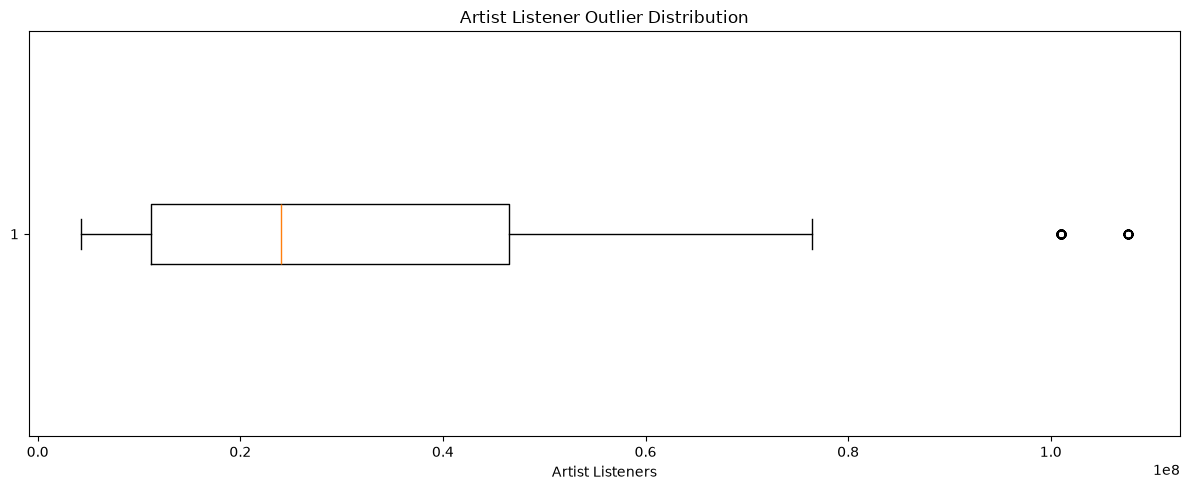

In [53]:
# Create a horizontal boxplot of artist listener counts
plt.figure(figsize=(12, 5))

plt.boxplot(
    listener_values,
    vert=False
)

plt.title("Artist Listener Outlier Distribution")
plt.xlabel("Artist Listeners")

plt.tight_layout()
plt.show()

In [54]:
# Inspect the largest listener outliers

listener_outlier_columns = [
    "Artist",
    "Listeners",
    "PkListeners",
    "Peak",
    "Daily Trend"
]

listener_outliers[
    listener_outlier_columns
].sort_values(
    "Listeners",
    ascending=False
).head(20).style.format({
    "Listeners": "{:,.0f}",
    "PkListeners": "{:,.0f}",
    "Peak": "{:,.0f}",
    "Daily Trend": "{:,.0f}"
})

,Artist,Listeners,PkListeners,Peak,Daily Trend
3563,The Weeknd,"107,592,328","113,034,886",1,"-138,880"
1428,The Weeknd,"107,592,328","113,034,886",1,"-138,880"
1088,The Weeknd,"107,592,328","113,034,886",1,"-138,880"
1144,The Weeknd,"107,592,328","113,034,886",1,"-138,880"
55,The Weeknd,"107,592,328","113,034,886",1,"-138,880"
1198,The Weeknd,"107,592,328","113,034,886",1,"-138,880"
1275,The Weeknd,"107,592,328","113,034,886",1,"-138,880"
3501,The Weeknd,"107,592,328","113,034,886",1,"-138,880"
2053,The Weeknd,"107,592,328","113,034,886",1,"-138,880"
885,The Weeknd,"107,592,328","113,034,886",1,"-138,880"


In [55]:
# Count unique artists among listener outlier records
unique_listener_outlier_artists = (
    listener_outliers[
        ["Artist", "Listeners", "PkListeners", "Peak", "Daily Trend"]
    ]
    .drop_duplicates(subset=["Artist"])
    .sort_values("Listeners", ascending=False)
)

print(
    f"Listener outlier records: "
    f"{len(listener_outliers):,}"
)

print(
    f"Unique artists represented: "
    f"{unique_listener_outlier_artists['Artist'].nunique():,}"
)

# Display unique artists with outlying listener counts
unique_listener_outlier_artists.style.format({
    "Listeners": "{:,.0f}",
    "PkListeners": "{:,.0f}",
    "Peak": "{:,.0f}",
    "Daily Trend": "{:,.0f}"
})

Listener outlier records: 94
Unique artists represented: 2


,Artist,Listeners,PkListeners,Peak,Daily Trend
55,The Weeknd,"107,592,328","113,034,886",1,"-138,880"
16,Taylor Swift,"101,003,302","101,003,302",2,889


### Listener Outlier Interpretation

The IQR analysis identified 94 track-level records with artist listener values above the upper outlier boundary of approximately 99.63 million listeners. However, further investigation showed that these records represent only two unique artists: The Weeknd and Taylor Swift.

The Weeknd recorded approximately 107.59 million listeners, while Taylor Swift recorded approximately 101.00 million listeners. Both values exceed the calculated upper outlier boundary, indicating exceptionally large listener audiences relative to the majority of artists represented in the integrated dataset.

The difference between the number of outlier records and unique artists is caused by the structure of the integrated dataset. The dataset contains track-level observations, while listener statistics are artist-level measurements. Therefore, an artist's listener statistics are repeated across multiple tracks associated with that artist.

This distinction is important for later analysis and machine-learning development. Treating all 94 records as independent artist-level outliers could overrepresent highly prolific artists and introduce bias into models that use listener statistics. Artist-level features may therefore require aggregation, deduplication or careful treatment during feature engineering.

These extreme listener values should not automatically be removed because they represent meaningful real-world differences in artist audience size rather than clear data errors.

## 9.3 Chart Performance Outliers

This section investigates unusual historical chart performance within the integrated PMIP dataset.

Unlike streaming and listener metrics, chart position uses an inverse ranking scale where smaller values represent stronger performance. For example, a chart position of 1 represents better performance than a chart position of 50. Therefore, chart-position values must be interpreted carefully when identifying unusual observations.

The analysis focuses on historical chart-performance features including:

- `best_chart_position` — the strongest historical chart position achieved by a track;
- `average_chart_position` — the average historical chart position of a track;
- `chart_observations` — the number of historical chart records associated with a track; and
- `countries_charted` — the number of countries in which a track appeared on historical charts.

The objective is to identify tracks with unusually extensive chart activity or geographic reach and determine whether these observations represent genuine high-performing releases or possible data-quality issues.

In [56]:
# Select non-missing historical chart observation values
chart_observation_data = df["chart_observations"].dropna()

# Calculate quartiles
q1_chart = chart_observation_data.quantile(0.25)
q3_chart = chart_observation_data.quantile(0.75)

# Calculate interquartile range
iqr_chart = q3_chart - q1_chart

# Calculate outlier boundaries
lower_chart_bound = q1_chart - (1.5 * iqr_chart)
upper_chart_bound = q3_chart + (1.5 * iqr_chart)

# Identify chart observation outliers
chart_observation_outliers = df[
    (df["chart_observations"] < lower_chart_bound)
    | (df["chart_observations"] > upper_chart_bound)
].copy()

# Calculate percentage of observations identified as outliers
chart_outlier_percentage = (
    len(chart_observation_outliers) / len(chart_observation_data)
) * 100

# Display results
print(f"Q1: {q1_chart:,.2f}")
print(f"Q3: {q3_chart:,.2f}")
print(f"IQR: {iqr_chart:,.2f}")
print(f"Lower outlier boundary: {lower_chart_bound:,.2f}")
print(f"Upper outlier boundary: {upper_chart_bound:,.2f}")

print()
print(f"Total observations analysed: {len(chart_observation_data):,}")
print(f"Chart observation outliers detected: {len(chart_observation_outliers):,}")
print(f"Percentage identified as outliers: {chart_outlier_percentage:.2f}%")

Q1: 70.00
Q3: 1,323.50
IQR: 1,253.50
Lower outlier boundary: -1,810.25
Upper outlier boundary: 3,203.75

Total observations analysed: 2,235
Chart observation outliers detected: 179
Percentage identified as outliers: 8.01%


/var/folders/8w/59s2t7hd74g4f203_5w8w38r0000gp/T/ipykernel_88744/2694281065.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


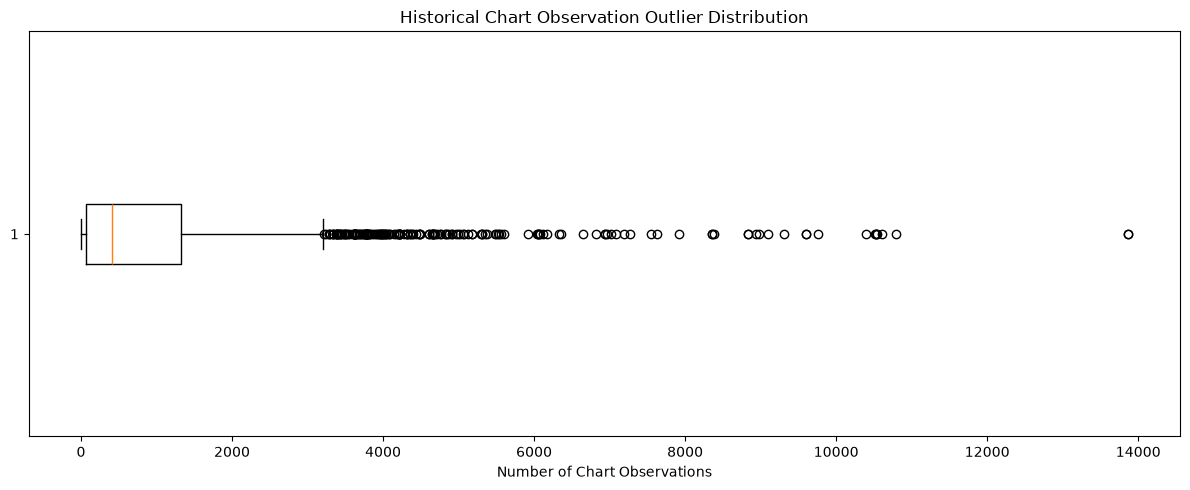

In [57]:
# Create a boxplot of historical chart observations
plt.figure(figsize=(12, 5))

plt.boxplot(
    chart_observation_data,
    vert=False
)

plt.title("Historical Chart Observation Outlier Distribution")
plt.xlabel("Number of Chart Observations")

plt.tight_layout()
plt.show()

In [58]:
# Select useful columns for inspecting chart observation outliers
chart_outlier_details = chart_observation_outliers[
    [
        "Track",
        "Artist",
        "chart_observations",
        "countries_charted",
        "best_chart_position",
        "average_chart_position",
        "total_historical_streams"
    ]
].copy()

# Sort tracks by number of historical chart observations
chart_outlier_details = chart_outlier_details.sort_values(
    "chart_observations",
    ascending=False
)

# Display the 20 most extreme chart observation outliers
chart_outlier_details.head(20).style.format({
    "chart_observations": "{:,.0f}",
    "countries_charted": "{:,.0f}",
    "best_chart_position": "{:,.0f}",
    "average_chart_position": "{:,.2f}",
    "total_historical_streams": "{:,.0f}"
})

,Track,Artist,chart_observations,countries_charted,best_chart_position,average_chart_position,total_historical_streams
1295,Take Me to Church,Hozier,"13,860",62,1,99.27,"3,423,226,172"
2278,Take Me to Church,Hozier,"13,860",62,1,99.27,"3,423,226,172"
53,Shape of You,Ed Sheeran,"10,788",70,1,84.95,"5,677,110,656"
262,Starboy,The Weeknd,"10,607",73,1,92.16,"5,048,247,849"
118,Believer,Imagine Dragons,"10,539",70,2,110.54,"3,584,990,979"
3260,Thinking out Loud,Ed Sheeran,"10,530",65,1,93.27,"2,238,141,951"
694,Thinking Out Loud,Ed Sheeran,"10,530",65,1,93.27,"2,238,141,951"
982,Photograph,Ed Sheeran,"10,516",65,1,101.61,"2,107,180,916"
2217,"Lose Yourself - From ""8 Mile"" Soundtrack",Eminem,"10,398",52,23,155.20,"2,244,936,835"
55,Blinding Lights,The Weeknd,"9,765",72,1,59.58,"6,226,855,629"


### Chart Performance Outlier Interpretation

The IQR analysis identified 179 records with more than approximately 3,204 historical chart observations, representing 8.01% of the 2,235 records containing historical chart data.

Inspection of the most extreme observations suggests that many of these outliers represent genuinely successful and persistent releases rather than obvious data-quality errors. For example, *Take Me to Church* recorded 13,860 historical chart observations across 62 countries, while *Shape of You* recorded 10,788 observations across 70 countries. Other highly represented tracks also demonstrated extensive international chart coverage, strong peak positions and substantial historical streaming totals.

The results therefore indicate that unusually high chart-observation counts can represent long-term chart persistence and international reach. These observations contain potentially valuable information for PMIP because they distinguish tracks with sustained historical performance from tracks with shorter or more geographically limited chart activity.

Some track-and-artist combinations appear more than once within the integrated dataset. Therefore, the 179 outlier records should not automatically be interpreted as 179 unique releases. Duplicate source identities and repeated track records should be considered during feature engineering to prevent particular releases from being overrepresented.

The chart-performance outliers should not automatically be removed. Instead, features such as `chart_observations`, `countries_charted`, `best_chart_position` and historical streaming metrics should be retained and potentially transformed or scaled during feature engineering. These variables may provide useful signals for later PMIP forecasting, momentum and performance-intelligence models.

## 10 — EDA Findings and ML Implications

This section summarises the main findings obtained during exploratory data analysis and considers their implications for the next stages of the Public Music Intelligence Platform (PMIP).

The purpose is to translate the statistical and visual findings into practical decisions for feature engineering and machine-learning development. Particular attention is given to important performance relationships, potentially useful predictive variables, possible target variables, data limitations and transformations that may be required before model training.

### 10.1 Key Findings

The exploratory analysis identified several important patterns within the integrated PMIP dataset.

These findings summarise the strongest evidence obtained from the distribution, relationship, correlation and outlier analyses performed in the previous sections.

#### Key EDA Findings

**1. Music performance variables are highly skewed**

Spotify streams, artist listener statistics and historical streaming measures show strongly uneven distributions. Most tracks and artists occupy lower or moderate performance ranges, while a relatively small number achieve extremely high values.

This suggests that transformations such as logarithmic scaling may be useful during feature engineering, particularly for streaming and listener variables.

**2. Spotify popularity and total Spotify streams are related, but they measure different aspects of performance**

The analysis found a Pearson correlation of approximately **0.360** between Spotify Streams and Spotify Popularity across 3,779 complete observations.

This represents a moderate positive relationship. Tracks with more streams therefore tend to have higher popularity values, but stream count alone does not completely explain Spotify Popularity.

**3. Track Score has a weaker relationship with Spotify Streams**

Spotify Streams and Track Score produced a Pearson correlation of approximately **0.251** across 4,485 complete observations.

This weak positive relationship suggests that Track Score contains information that is not simply a direct representation of Spotify streaming volume.

**4. Historical streaming performance is strongly related to current Spotify streaming performance**

One of the strongest findings was the relationship between `total_historical_streams` and Spotify Streams.

Across 2,220 complete observations, the two variables produced a Pearson correlation of approximately **0.805**, indicating a strong positive relationship.

This suggests that historical streaming performance may provide an important predictive signal when developing PMIP performance models.

**5. Geographic chart reach contains meaningful performance information**

Historical chart variables showed that highly successful tracks frequently appeared across many countries. Measures such as `countries_charted` may therefore provide useful information about the international reach of a release.

This is particularly relevant to PMIP's geographic performance and market intelligence components.

**6. Chart-position variables require careful interpretation**

Lower numerical chart positions represent better performance. For example, position 1 represents stronger chart performance than position 100.

Consequently, negative correlations involving `best_chart_position` or `average_chart_position` do not necessarily represent negative performance relationships. They may instead indicate that stronger-performing tracks achieve lower numerical chart positions while producing higher streaming, listener or geographic performance values.

**7. Several numerical features are strongly related**

The correlation analysis identified relationships between historical streams, chart activity, geographic reach, artist listener statistics and current Spotify performance.

Highly correlated variables may provide useful predictive information, but they may also introduce redundant information into some machine-learning models. These relationships should therefore be reviewed during feature selection.

**8. Extreme observations are common and often represent genuine music success**

The outlier analysis identified substantial high-end observations in streaming, listener and historical chart variables.

For example, 289 Spotify streaming observations were identified as IQR outliers, representing approximately **6.44%** of the analysed Spotify streaming records. Historical chart observations contained 179 outlier records, representing approximately **8.01%** of records with historical chart information.

Inspection showed that many of these observations correspond to highly successful tracks rather than obvious data errors. They should therefore not automatically be removed.

**9. Some track identities appear more than once**

Inspection of extreme observations revealed repeated track-and-artist combinations within the integrated dataset.

These records may originate from different source identities or versions of the same release. They should be investigated during feature engineering to prevent repeated releases from unintentionally influencing model training or evaluation.

**10. Missing data remains important**

Not every Spotify record contains matching historical chart or artist listener information because the original datasets provide different levels of coverage.

Machine-learning datasets will therefore need model-specific missing-value strategies rather than automatically removing every incomplete record.

### 10.2 Potential Predictive Features

The exploratory analysis identified several variables that may provide useful predictive information for the machine-learning components of PMIP.

At this stage, these variables are considered **candidate predictive features** rather than final model inputs. Their suitability will be investigated further during feature engineering, where issues such as missing values, skewness, redundancy, data leakage and model-specific requirements will be considered.

The candidate features can be grouped into current performance, artist audience, historical performance and geographic performance indicators.

In [59]:
# Define candidate predictive features identified during EDA
candidate_features = [
    # Current performance features
    "Spotify Popularity",
    "Track Score",
    
    # Artist audience features
    "Listeners",
    "Daily Trend",
    "Peak",
    "PkListeners",
    
    # Historical chart performance features
    "best_chart_position",
    "average_chart_position",
    "chart_observations",
    "total_historical_streams",
    "average_historical_streams",
    "max_historical_streams",
    
    # Geographic performance feature
    "countries_charted"
]

# Keep only features that exist in the integrated dataset
available_candidate_features = [
    feature for feature in candidate_features
    if feature in df.columns
]

print(f"Candidate predictive features identified: {len(available_candidate_features)}")
print()

for feature in available_candidate_features:
    print(f"- {feature}")

Candidate predictive features identified: 13

- Spotify Popularity
- Track Score
- Listeners
- Daily Trend
- Peak
- PkListeners
- best_chart_position
- average_chart_position
- chart_observations
- total_historical_streams
- average_historical_streams
- max_historical_streams
- countries_charted


#### Interpretation

The EDA suggests that historical performance variables may be particularly valuable for predictive modelling.

`total_historical_streams` showed a strong positive relationship with current Spotify Streams, while `chart_observations`, `countries_charted` and `max_historical_streams` also showed meaningful relationships with current and historical performance measures.

Artist audience variables such as `Listeners` and `PkListeners` may provide additional information about the size of an artist's audience. However, these two variables are extremely strongly correlated with each other, with a correlation of approximately 0.993. Including both may therefore provide largely duplicated information for some models and should be investigated during feature selection.

Chart-position variables may also contain useful predictive information, but their direction requires careful interpretation because lower numerical positions represent better chart performance.

Several streaming and listener variables are strongly right-skewed and contain legitimate extreme observations. Transformations such as logarithmic scaling should therefore be investigated before model training rather than automatically removing high-performing records.

The final feature set should depend on the specific PMIP model being developed. Artist forecasting, momentum scoring, anomaly detection, geographic intelligence and release-performance analysis may require different combinations of these variables.

### 10.3 Potential Target Variables

A target variable represents the outcome that a supervised machine-learning model attempts to predict.

Based on the available PMIP data and the findings from exploratory analysis, several variables could potentially serve as prediction targets. The appropriate target will depend on the specific intelligence task being developed.

This section identifies potential targets for later investigation rather than selecting a final modelling target.

In [60]:
# Define potential target variables identified from the EDA
potential_targets = [
    "Spotify Streams",
    "Spotify Popularity",
    "Track Score",
    "Listeners",
    "Daily Trend",
    "Peak",
    "best_chart_position",
    "average_chart_position",
    "chart_observations",
    "countries_charted",
    "total_historical_streams",
    "max_historical_streams"
]

# Keep only targets available in the integrated dataset
available_targets = [
    target for target in potential_targets
    if target in df.columns
]

print(f"Potential target variables identified: {len(available_targets)}")
print()

for target in available_targets:
    print(f"- {target}")

Potential target variables identified: 12

- Spotify Streams
- Spotify Popularity
- Track Score
- Listeners
- Daily Trend
- Peak
- best_chart_position
- average_chart_position
- chart_observations
- countries_charted
- total_historical_streams
- max_historical_streams


#### Interpretation

Several potential target variables are available, but they represent different prediction problems.

**Spotify Streams** is a strong candidate for modelling overall track streaming performance. The EDA found strong relationships between Spotify Streams and historical performance measures, particularly `total_historical_streams` and `chart_observations`. This makes it a potentially useful target for investigating whether historical and artist-level information can explain or predict streaming performance.

**Spotify Popularity** could be investigated as an alternative measure of current track performance. However, it should not be treated as equivalent to Spotify Streams because the EDA showed only a moderate relationship between the two variables.

**Track Score** could potentially represent broader cross-platform track performance, although its meaning and construction should be reviewed carefully before using it as a supervised-learning target.

**Listeners** and **Daily Trend** may support artist-level modelling. Listener information could represent audience size, while Daily Trend may provide information about shorter-term changes in artist performance.

Historical variables such as `best_chart_position`, `average_chart_position`, `chart_observations`, `countries_charted`, `total_historical_streams` and `max_historical_streams` could support models concerned with chart success, geographic reach or historical performance.

Not every PMIP intelligence component necessarily requires a supervised target variable. Artist momentum scoring may combine several performance indicators into an interpretable score, while anomaly detection may use unsupervised techniques to identify unusual behaviour without a predefined target.

The final target for each model should therefore be selected according to the specific PMIP intelligence problem, the available observations and the risk of data leakage.

### 10.4 Data Limitations

Although the integrated PMIP dataset provides useful information for exploratory analysis and future machine-learning development, several limitations must be considered when interpreting the results and designing predictive models.

#### Incomplete Dataset Coverage

The original datasets do not provide complete information for every track and artist. Historical chart features are available only for records that could be matched with the historical chart dataset, while artist listener statistics are available only where artist identities could be successfully matched.

As a result, some observations contain missing historical or artist-level information. Removing all incomplete records could substantially reduce the available training data and potentially introduce bias. Missing-data strategies should therefore be selected according to the requirements of each model.

#### Dataset Integration and Matching

The integrated dataset was constructed by matching information from different music datasets. Differences in track names, artist formatting, collaborations and source identifiers can make exact matching difficult.

Normalised track and artist keys improved integration, but some valid relationships may remain unmatched. Conversely, different releases or versions with similar names may require additional investigation before machine-learning development.

#### Repeated Track and Artist Records

The EDA identified repeated track-and-artist combinations within the integrated data. Some of these records may represent different source identities, releases or versions rather than exact duplicate rows.

This is important for machine learning because related versions of the same track appearing across both training and testing data could make model performance appear stronger than it really is. Appropriate grouping or deduplication strategies should therefore be investigated before dataset splitting.

#### Highly Skewed Performance Variables

Streaming, listener and historical performance variables are strongly right-skewed. A relatively small number of highly successful tracks and artists account for extremely large performance values.

These observations are not necessarily errors. Many represent genuine high-performing releases and should not automatically be removed. Logarithmic transformations, robust scaling or models that are less sensitive to extreme values should be investigated during feature engineering.

#### Correlated and Potentially Redundant Features

Several variables contain strongly overlapping information. For example, `Listeners` and `PkListeners` showed an extremely strong positive correlation, while historical streaming and chart activity variables also displayed substantial relationships.

Using several highly correlated predictors may introduce unnecessary redundancy and may affect the interpretation of some models. Feature selection and multicollinearity analysis should therefore be performed before final model training.

#### Interpretation of Chart Positions

Chart-position variables have an inverse numerical meaning. A smaller chart position represents stronger performance; for example, position 1 is better than position 100.

Negative correlations involving chart-position variables must therefore be interpreted carefully because a decreasing numerical value can represent improving performance.

#### Temporal Limitations

The integrated dataset combines current or snapshot performance measures with aggregated historical chart information. Although historical features provide valuable information about previous performance, the current dataset is not automatically a complete time-series forecasting dataset.

A forecasting model must ensure that predictor variables represent information that would have been available before the outcome being predicted. Otherwise, future information could unintentionally enter the training features and cause data leakage.

#### Correlation Does Not Establish Causation

The relationships identified during EDA describe statistical associations between variables. Strong correlation does not demonstrate that one performance measure directly causes another.

For example, the strong relationship between historical streams and current Spotify Streams indicates that the variables move together, but it does not establish that historical streams alone cause future streaming success.

#### Dataset and Platform Representation

The available datasets represent particular music platforms, chart observations and measurement periods. They may not capture every factor influencing music performance, such as marketing campaigns, social-media activity, playlist placement, radio exposure, live performances, fan engagement or external cultural events.

Predictions produced by PMIP should therefore be interpreted as data-driven estimates based on the available variables rather than complete explanations of artist or release success.

### 10.5 Recommendations for Feature Engineering

The exploratory data analysis identified several characteristics of the integrated PMIP dataset that should guide the feature engineering and machine-learning stages.

#### 1. Transform Highly Skewed Performance Variables

Several streaming and listener variables contain very large ranges and strong right-skewed distributions. These include Spotify streams, artist listeners and historical streaming measures.

Logarithmic transformations should be investigated for variables such as:

- `Spotify Streams`
- `Listeners`
- `PkListeners`
- `total_historical_streams`
- `average_historical_streams`
- `max_historical_streams`
- `chart_observations`

Transforming these variables may reduce the influence of extremely large observations and make underlying relationships easier for some machine-learning models to learn.

#### 2. Preserve Genuine High-Performance Observations

The outlier analysis identified highly successful tracks and artists with exceptionally large streaming, listener and historical chart values. Many of these observations represent genuine music-performance behaviour rather than data errors.

These records should therefore not be automatically removed. Robust scaling, transformations and suitable modelling techniques should be considered before deciding whether any observations require exclusion.

#### 3. Address Highly Correlated Features

The correlation analysis identified several strongly related variables. In particular, `Listeners` and `PkListeners` showed an extremely strong positive relationship.

Historical variables such as `chart_observations`, `total_historical_streams`, `countries_charted` and `max_historical_streams` also contain overlapping information.

Feature selection should therefore investigate whether all correlated variables are necessary for each model. Removing redundant variables may simplify models and improve interpretability.

#### 4. Engineer Historical Performance Features

The strong relationships between historical chart activity and current Spotify performance suggest that historical performance contains valuable predictive information.

Potential derived features could include:

- historical streaming intensity;
- chart longevity;
- international chart reach;
- average streams per chart observation;
- peak-to-average chart performance;
- historical performance consistency; and
- relative chart success indicators.

These features could provide more meaningful information than using raw historical measurements alone.

#### 5. Engineer Artist-Level Performance Features

Artist listener statistics provide additional information about audience size and artist reach.

Potential features could include:

- listener-to-peak-listener ratios;
- current audience strength;
- listener growth indicators using `Daily Trend`;
- artist reach categories; and
- artist-level performance summaries.

Care should be taken when the same artist appears across multiple tracks because artist-level variables may be repeated across several records.

#### 6. Handle Chart Positions Carefully

Chart positions should not be interpreted like ordinary numerical performance variables because smaller values indicate better performance.

Derived variables may therefore be created so that increasing values consistently represent stronger performance. This could make model interpretation easier and reduce confusion when analysing feature importance.

#### 7. Develop Geographic Performance Features

The `countries_charted` variable demonstrated meaningful relationships with streaming and historical performance.

Additional geographic features could therefore include:

- international reach;
- number of active markets;
- geographic performance breadth; and
- country-level performance indicators where the historical data supports them.

These features may later support PMIP's geographic performance and market intelligence components.

#### 8. Develop Release and Track-Level Features

Release information and track characteristics should be investigated for additional derived variables, including:

- release year;
- release age;
- track performance relative to an artist's other releases;
- platform performance ratios; and
- combined popularity or performance indicators.

These features may help PMIP compare releases at different stages of their performance lifecycle.

#### 9. Define Features Separately for Each PMIP Model

A single feature set should not automatically be used for every machine-learning task.

Different PMIP components may require different combinations of variables depending on whether the objective is forecasting performance, measuring artist momentum, detecting streaming anomalies or identifying market growth.

Feature engineering should therefore be performed with the specific prediction problem and target variable clearly defined.

#### 10. Prevent Data Leakage

Before model training, each feature must be checked to ensure that it would realistically be available at the time a prediction is made.

Historical or current performance information that contains knowledge of the outcome being predicted must not be used as an input feature.

This is particularly important for PMIP's forecasting models, where the distinction between historical information and future outcomes must remain clear.

#### 11. Use Appropriate Data Splitting Strategies

Repeated tracks, artists and related releases should be considered when constructing training, validation and testing datasets.

Where necessary, artist-level or track-level grouping should be used to prevent closely related records from appearing across different dataset partitions and producing overly optimistic model evaluation results.

#### Overall Recommendation

The feature engineering stage should retain the useful information identified during EDA while reducing skewness, redundancy and potential data leakage. Particular attention should be given to historical performance, artist audience size, chart activity and geographic reach because these variables demonstrated meaningful relationships with music performance.

The resulting features should be designed around the specific intelligence tasks provided by PMIP rather than creating one general-purpose feature set for every model.

## EDA Summary and Conclusion

The exploratory data analysis provided a clearer understanding of the performance patterns, relationships and limitations within the integrated Public Music Intelligence Platform (PMIP) dataset.

### Main Findings

The analysis showed that music performance variables are generally highly skewed. Spotify streams, artist listeners and historical streaming measures contain relatively small numbers of extremely high-performing observations. These observations largely represent genuine successful artists and tracks rather than obvious data errors and should therefore not be automatically removed during later modelling.

Current Spotify performance showed meaningful relationships with historical performance. In particular, Spotify Streams and total historical streams produced a strong positive Pearson correlation of approximately **0.805**. Spotify Streams also showed strong positive relationships with chart observations and the number of countries in which a track charted. This suggests that historical chart activity and international reach may provide useful information when modelling current or future music performance.

Artist audience variables also demonstrated important relationships. `Listeners` and `PkListeners` produced an extremely strong positive correlation of approximately **0.993**, indicating that the two variables contain very similar information. This relationship should be considered during feature selection to avoid unnecessary redundancy.

Spotify Streams showed weaker positive relationships with Spotify Popularity (**0.360**), Artist Listeners (**0.300**) and Track Score (**0.251**). These results indicate that although these variables are related to streaming performance, no individual variable completely explains the differences in track performance.

The historical chart variables provided some of the strongest relationships identified during the analysis. `chart_observations`, `countries_charted`, `total_historical_streams` and `max_historical_streams` were strongly associated with several measures of music performance. These variables therefore represent important candidates for later feature engineering.

Negative correlations involving chart position require careful interpretation because lower chart-position numbers represent better performance. For example, a track reaching position 1 has performed better than a track reaching position 100. Negative relationships between chart position and streaming or geographic performance may therefore represent stronger rather than weaker music performance.

### Outlier Findings

The outlier analysis identified substantial differences between typical and exceptionally successful music records.

For Spotify Streams, **289 of 4,485 observations (6.44%)** were identified as upper outliers using the IQR method. These included globally successful tracks with several billion Spotify streams.

For Artist Listeners, **94 of 3,389 records (2.77%)** were identified as outliers. However, these records represented only **two unique artists**, demonstrating that artist-level listener statistics are repeated across multiple track records in the integrated dataset.

For historical chart observations, **179 of 2,235 records (8.01%)** were identified as outliers. These records largely represented tracks with unusually long or widespread historical chart presence.

These findings demonstrate that extreme values within PMIP often contain meaningful information about highly successful artists and tracks. Future preprocessing should therefore consider transformations and robust modelling techniques rather than automatically deleting these observations.

### Implications for Machine Learning

The EDA identified several potentially useful predictive variables, particularly those representing historical streaming performance, chart activity, international reach, artist audience size and current platform performance.

However, feature selection must account for highly correlated variables, repeated artist-level information, skewed distributions and missing historical observations. Appropriate transformations and feature engineering will therefore be required before model development.

Different PMIP intelligence components may also require different feature sets and target variables. Artist performance forecasting, momentum scoring, anomaly detection, geographic intelligence and market growth detection should therefore be treated as separate analytical problems rather than relying on one universal model.

Data leakage must also be carefully controlled. Variables used to predict future performance must contain only information that would realistically have been available before the predicted outcome occurred.

### Conclusion

Overall, the exploratory data analysis demonstrates that the integrated PMIP dataset contains meaningful relationships between current Spotify performance, historical chart behaviour, geographic reach and artist audience statistics.

The results provide a strong analytical foundation for the next stage of the project: **feature engineering for PMIP's machine-learning and music intelligence components**. The next stage should transform the most informative variables into model-ready features while addressing skewness, redundancy, repeated artist information, missing values and potential data leakage.